# EXPLORATORY DATA ANALYSIS(EDA) AND MODELLING

### Importing Libraries

In this section, we import the necessary Python libraries for data analysis and preprocessing.



In [1]:
# pip install shap


In [2]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, precision_score, recall_score, f1_score,roc_curve,precision_recall_curve
)


import shap
import time
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb



sns.set_theme(style="whitegrid", palette="viridis")

import warnings
warnings.filterwarnings('ignore')


#get the parent directory of the current file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)


# get the path to the data folder
data_path = os.path.join(
    parent_dir,
    "Data sets"
)

model_path = os.path.join(
    parent_dir ,
    "Models"
)

c:\Users\hp\anaconda3\envs\learn-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the Dataset

In this step, we load the cleaned dataset into the notebook using pandas.

In [3]:

final_data= pd.read_csv(os.path.join(data_path ,"Final_dataset.csv" ))
final_data.head()

,Unnamed: 0,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_size,farm_work,livestock,inorganic_fertilizer,...,cashflow_volatility,balance_stability,fraud_rate,input_efficiency,climate_risk_score,hh_shock,drought_shock,dist_market,country,main_crop_clean
0,0,13.0,0.3,44.4,1.0,1.0,3.103942,1.0,0.0,0.0,...,3.107012,4.965882e+07,0.636364,0.0,0.237516,1.0,0.000000,60.700001,Tanzania,OTHER
1,1,4.0,1.0,81.0,1.0,1.0,3.658361,0.0,0.0,0.0,...,1.592171,2.705629e+07,0.733333,0.0,0.258148,1.0,0.166667,60.700001,Tanzania,OTHER
2,2,4.0,3.0,72.0,1.0,1.0,1.210011,1.0,0.0,0.0,...,1.814533,1.185635e+08,0.250000,0.0,0.176846,0.0,0.000000,60.700001,Tanzania,MAIZE
3,3,2.0,1.0,31.0,0.0,1.0,3.354847,1.0,0.0,0.0,...,0.000000,2.933951e+07,0.000000,0.0,0.319816,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT
4,4,3.0,0.5,38.0,0.0,1.0,6.689459,1.0,0.0,0.0,...,1.300629,2.887447e+07,0.600000,0.0,0.226742,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT


---
## Exploratory Data Analysis (EDA)

This section provides a comprehensive exploration of the AgriScore dataset before any preprocessing or model training.
The goal is to understand the data's structure, distributions, relationships, and potential issues that may influence modelling decisions.


### 1. Dataset Overview

A high-level look at dataset dimensions, data types, and missing values.

In [4]:
# Shape & basic info 
print(f"Dataset shape: {final_data.shape[0]:,} rows × {final_data.shape[1]} columns")
print("\n DATA TYPES & NON-NULL COUNTS\n")
final_data.info()

Dataset shape: 11,408 rows × 34 columns

 DATA TYPES & NON-NULL COUNTS

<class 'pandas.DataFrame'>
RangeIndex: 11408 entries, 0 to 11407
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            11408 non-null  int64  
 1   hh_size               11408 non-null  float64
 2   hh_dependency_ratio   11408 non-null  float64
 3   age_manager           11408 non-null  float64
 4   hh_primary_education  11408 non-null  float64
 5   hh_formal_education   11408 non-null  float64
 6   farm_size             11408 non-null  float64
 7   farm_work             11408 non-null  float64
 8   livestock             11408 non-null  float64
 9   inorganic_fertilizer  11408 non-null  float64
 10  fertilizer_per_ha     11408 non-null  float64
 11  yield_kg_ha           11408 non-null  float64
 12  yield_stability       11408 non-null  float64
 13  yield_per_ha          11408 non-null  float64
 14  rainfall_

In [5]:
#Missing-value audit 
final_data.isnull().sum()

Unnamed: 0              0
hh_size                 0
hh_dependency_ratio     0
age_manager             0
hh_primary_education    0
hh_formal_education     0
farm_size               0
farm_work               0
livestock               0
inorganic_fertilizer    0
fertilizer_per_ha       0
yield_kg_ha             0
yield_stability         0
yield_per_ha            0
rainfall_mm             0
soil_quality_index      0
soil_npk                0
drought_risk            0
climate_stress_index    0
crop_health_index       0
tx_frequency            0
total_volume            0
avg_transaction         0
input_purchase_ratio    0
cashflow_volatility     0
balance_stability       0
fraud_rate              0
input_efficiency        0
climate_risk_score      0
hh_shock                0
drought_shock           0
dist_market             0
country                 0
main_crop_clean         0
dtype: int64

In [6]:
# Duplicate rows 
n_dupes = final_data.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 0


### 2. Summary Statistics

Descriptive statistics for all numerical features.

In [7]:
# Numerical summary
num_cols = final_data.select_dtypes(include=['number']).columns.tolist()
print(f"Numerical features ({len(num_cols)}): {num_cols}\n")
final_data[num_cols].describe().T.style.background_gradient(cmap='YlGnBu', axis=1)

Numerical features (32): ['Unnamed: 0', 'hh_size', 'hh_dependency_ratio', 'age_manager', 'hh_primary_education', 'hh_formal_education', 'farm_size', 'farm_work', 'livestock', 'inorganic_fertilizer', 'fertilizer_per_ha', 'yield_kg_ha', 'yield_stability', 'yield_per_ha', 'rainfall_mm', 'soil_quality_index', 'soil_npk', 'drought_risk', 'climate_stress_index', 'crop_health_index', 'tx_frequency', 'total_volume', 'avg_transaction', 'input_purchase_ratio', 'cashflow_volatility', 'balance_stability', 'fraud_rate', 'input_efficiency', 'climate_risk_score', 'hh_shock', 'drought_shock', 'dist_market']



,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,11408.000000,5703.500000,3293.350270,0.000000,2851.750000,5703.500000,8555.250000,11407.000000
hh_size,11408.000000,5.475456,3.182328,1.000000,3.000000,5.000000,7.000000,54.000000
hh_dependency_ratio,11408.000000,1.108056,0.943955,0.000000,0.500000,1.000000,1.500000,10.000000
age_manager,11408.000000,47.963876,14.378163,8.000000,37.000000,47.000000,56.000000,100.000000
hh_primary_education,11408.000000,0.472826,0.499283,0.000000,0.000000,0.000000,1.000000,1.000000
hh_formal_education,11408.000000,0.943899,0.230127,0.000000,1.000000,1.000000,1.000000,1.000000
farm_size,11408.000000,4.836789,205.394005,0.000000,0.485623,1.203941,2.557787,20977.708984
farm_work,11408.000000,0.669355,0.470466,0.000000,0.000000,1.000000,1.000000,1.000000
livestock,11408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
inorganic_fertilizer,11408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
# Categorical summary 
cat_cols = final_data.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical features ({len(cat_cols)}): {cat_cols}\n")


Categorical features (2): ['country', 'main_crop_clean']



### 3. Numerical Feature Distributions

Histograms with KDE overlays reveal the shape of each feature's distribution — whether it is normally distributed, skewed, bimodal, or contains heavy tails.

In [ ]:
# ── 4.1 Histograms + KDE for all numerical features 
# Focus on the raw pre-encoded numerical columns that are meaningful for EDA
eda_num_cols = [c for c in num_cols if c not in ['good_borrower']]

n_cols_plot = 3
n_rows_plot = -(-len(eda_num_cols) // n_cols_plot)  # ceiling division

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten()

for idx, col in enumerate(eda_num_cols):
    ax = axes[idx]
    sns.histplot(final_data[col].dropna(), kde=True, ax=ax,
                 color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Frequency')
    # Annotate skewness
    skew_val = final_data[col].skew()
    ax.annotate(f'Skew: {skew_val:.2f}', xy=(0.72, 0.90),
                xycoords='axes fraction', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions (Histogram + KDE)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

Value counts and bar plots reveal the cardinality and frequency balance of each categorical feature.

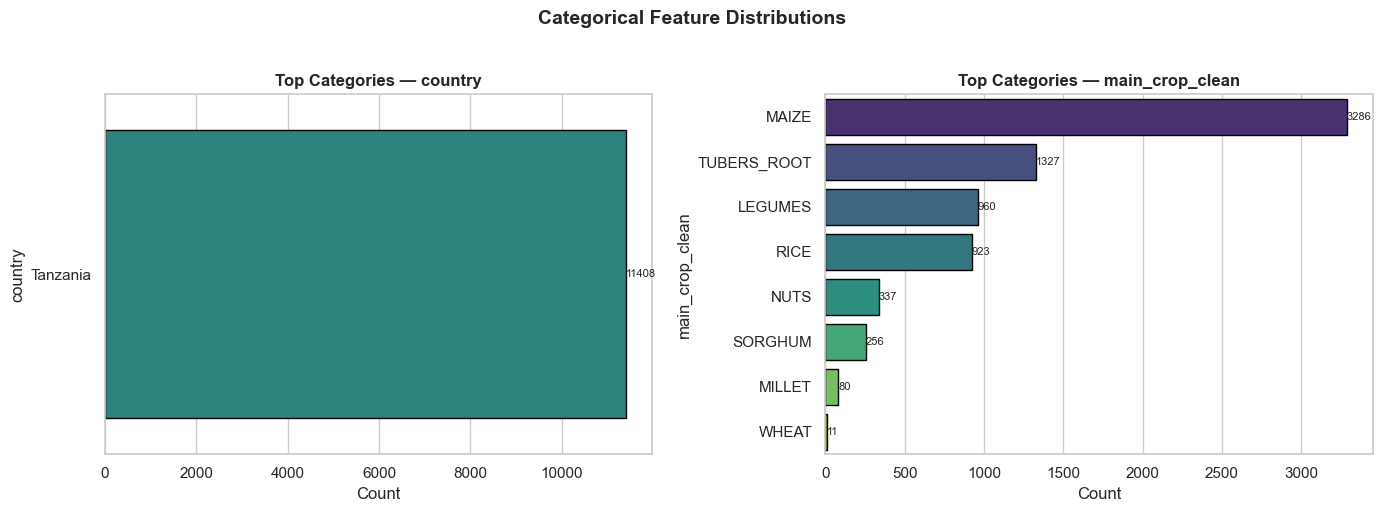

In [ ]:
# Categorical value-count bar plots 
# Identify original categorical columns before one-hot encoding
raw_cat_cols = final_data.select_dtypes(include=['object', 'category']).columns.tolist()

if raw_cat_cols:
    n_cats = len(raw_cat_cols)
    fig, axes = plt.subplots(1, n_cats, figsize=(7 * n_cats, 5))
    if n_cats == 1:
        axes = [axes]
    for ax, col in zip(axes, raw_cat_cols):
        # counts = final_data[col].value_counts().head(20)
         # Filter out 'OTHER' or 'other' from the value counts
        counts = final_data[col].value_counts()
        counts = counts[~counts.index.astype(str).str.upper().isin(['OTHER'])].head(20)
        
        sns.barplot(x=counts.values, y=counts.index, ax=ax,
                    palette='viridis', edgecolor='black')
        ax.set_title(f'Top Categories — {col}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Count')
        ax.set_ylabel(col)
        for i, v in enumerate(counts.values):
            ax.text(v + 1, i, str(v), va='center', fontsize=8)
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    
    country_cols = [c for c in final_data.columns if c.startswith('country_')]
    crop_cols    = [c for c in final_data.columns if c.startswith('main_crop_clean_')]

    
    print(f"  country dummies : {len(country_cols)} columns")
    print(f"  crop dummies    : {len(crop_cols)} columns")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Country frequency
    country_sums = final_data[country_cols].sum().sort_values(ascending=False).head(15)
    country_labels = [c.replace('country_', '') for c in country_sums.index]
    axes[0].barh(country_labels[::-1], country_sums.values[::-1],
                 color=sns.color_palette('viridis', len(country_sums)), edgecolor='black')
    axes[0].set_title('Top Countries by Sample Count', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Count')

    # Crop frequency
    crop_sums = final_data[crop_cols].sum().sort_values(ascending=False).head(15)
    crop_labels = [c.replace('main_crop_clean_', '') for c in crop_sums.index]
    axes[1].barh(crop_labels[::-1], crop_sums.values[::-1],
                 color=sns.color_palette('magma', len(crop_sums)), edgecolor='black')
    axes[1].set_title('Top Crops by Sample Count', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Count')

    plt.suptitle('Categorical Feature Distributions (One-Hot Encoded)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 5. Creating the Target Variable: Good Borrower

In this step, we define the target variable `good_borrower`, which represents whether a farmer is creditworthy or not.

A farmer is labeled as a **good borrower (1)** if they meet the following conditions:

- Their yield per hectare is above the median value  
- Their balance stability is above the median value  
- Their climate risk score is below the median value  

Otherwise, they are labeled as a **bad borrower (0)**.

This rule-based approach helps us create a clear classification target for the machine learning model.

In [ ]:

np.random.seed(42)

score = (
    (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()).astype(int) +
    (final_data['balance_stability'] > final_data['balance_stability'].median()).astype(int) +
    (final_data['climate_risk_score'] < final_data['climate_risk_score'].median()).astype(int)
)

# introduce randomness (real-world uncertainty)
final_data['good_borrower'] = np.where(
    (score + np.random.normal(0, 0.5, len(final_data))) > 2,
    1,
    0
)

### 6. Target Variable Distribution

Examining class balance for the `good_borrower` target variable is critical before training, as imbalance directly impacts model performance.

Class distribution:
  Class 0: 9,215 samples (80.8%)
  Class 1: 2,193 samples (19.2%)


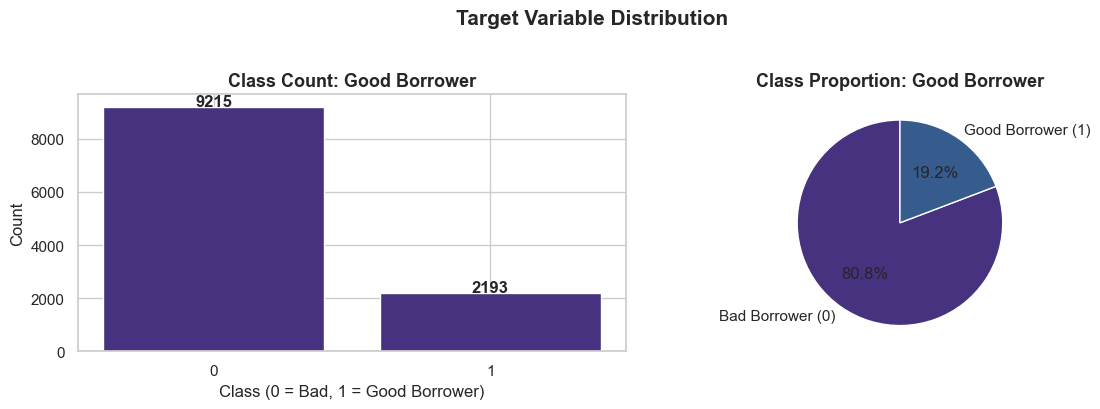

In [ ]:
# ── 3.1 Class counts & proportions ─────────────────────────────────
target_counts = final_data['good_borrower'].value_counts()
target_pct    = final_data['good_borrower'].value_counts(normalize=True) * 100

print("Class distribution:")
for cls in target_counts.index:
    print(f"  Class {cls}: {target_counts[cls]:,} samples ({target_pct[cls]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            # color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5
            )
axes[0].set_title('Class Count: Good Borrower', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Class (0 = Bad, 1 = Good Borrower)')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Bad Borrower (0)', 'Good Borrower (1)'],
            autopct='%1.1f%%', startangle=90,
            # colors=['#e74c3c', '#2ecc71'], wedgeprops={'edgecolor': 'white', 'linewidth': 2}
            )
axes[1].set_title('Class Proportion: Good Borrower', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

A Pearson correlation heatmap across numerical features identifies multicollinearity and features that are strongly associated with the target variable.

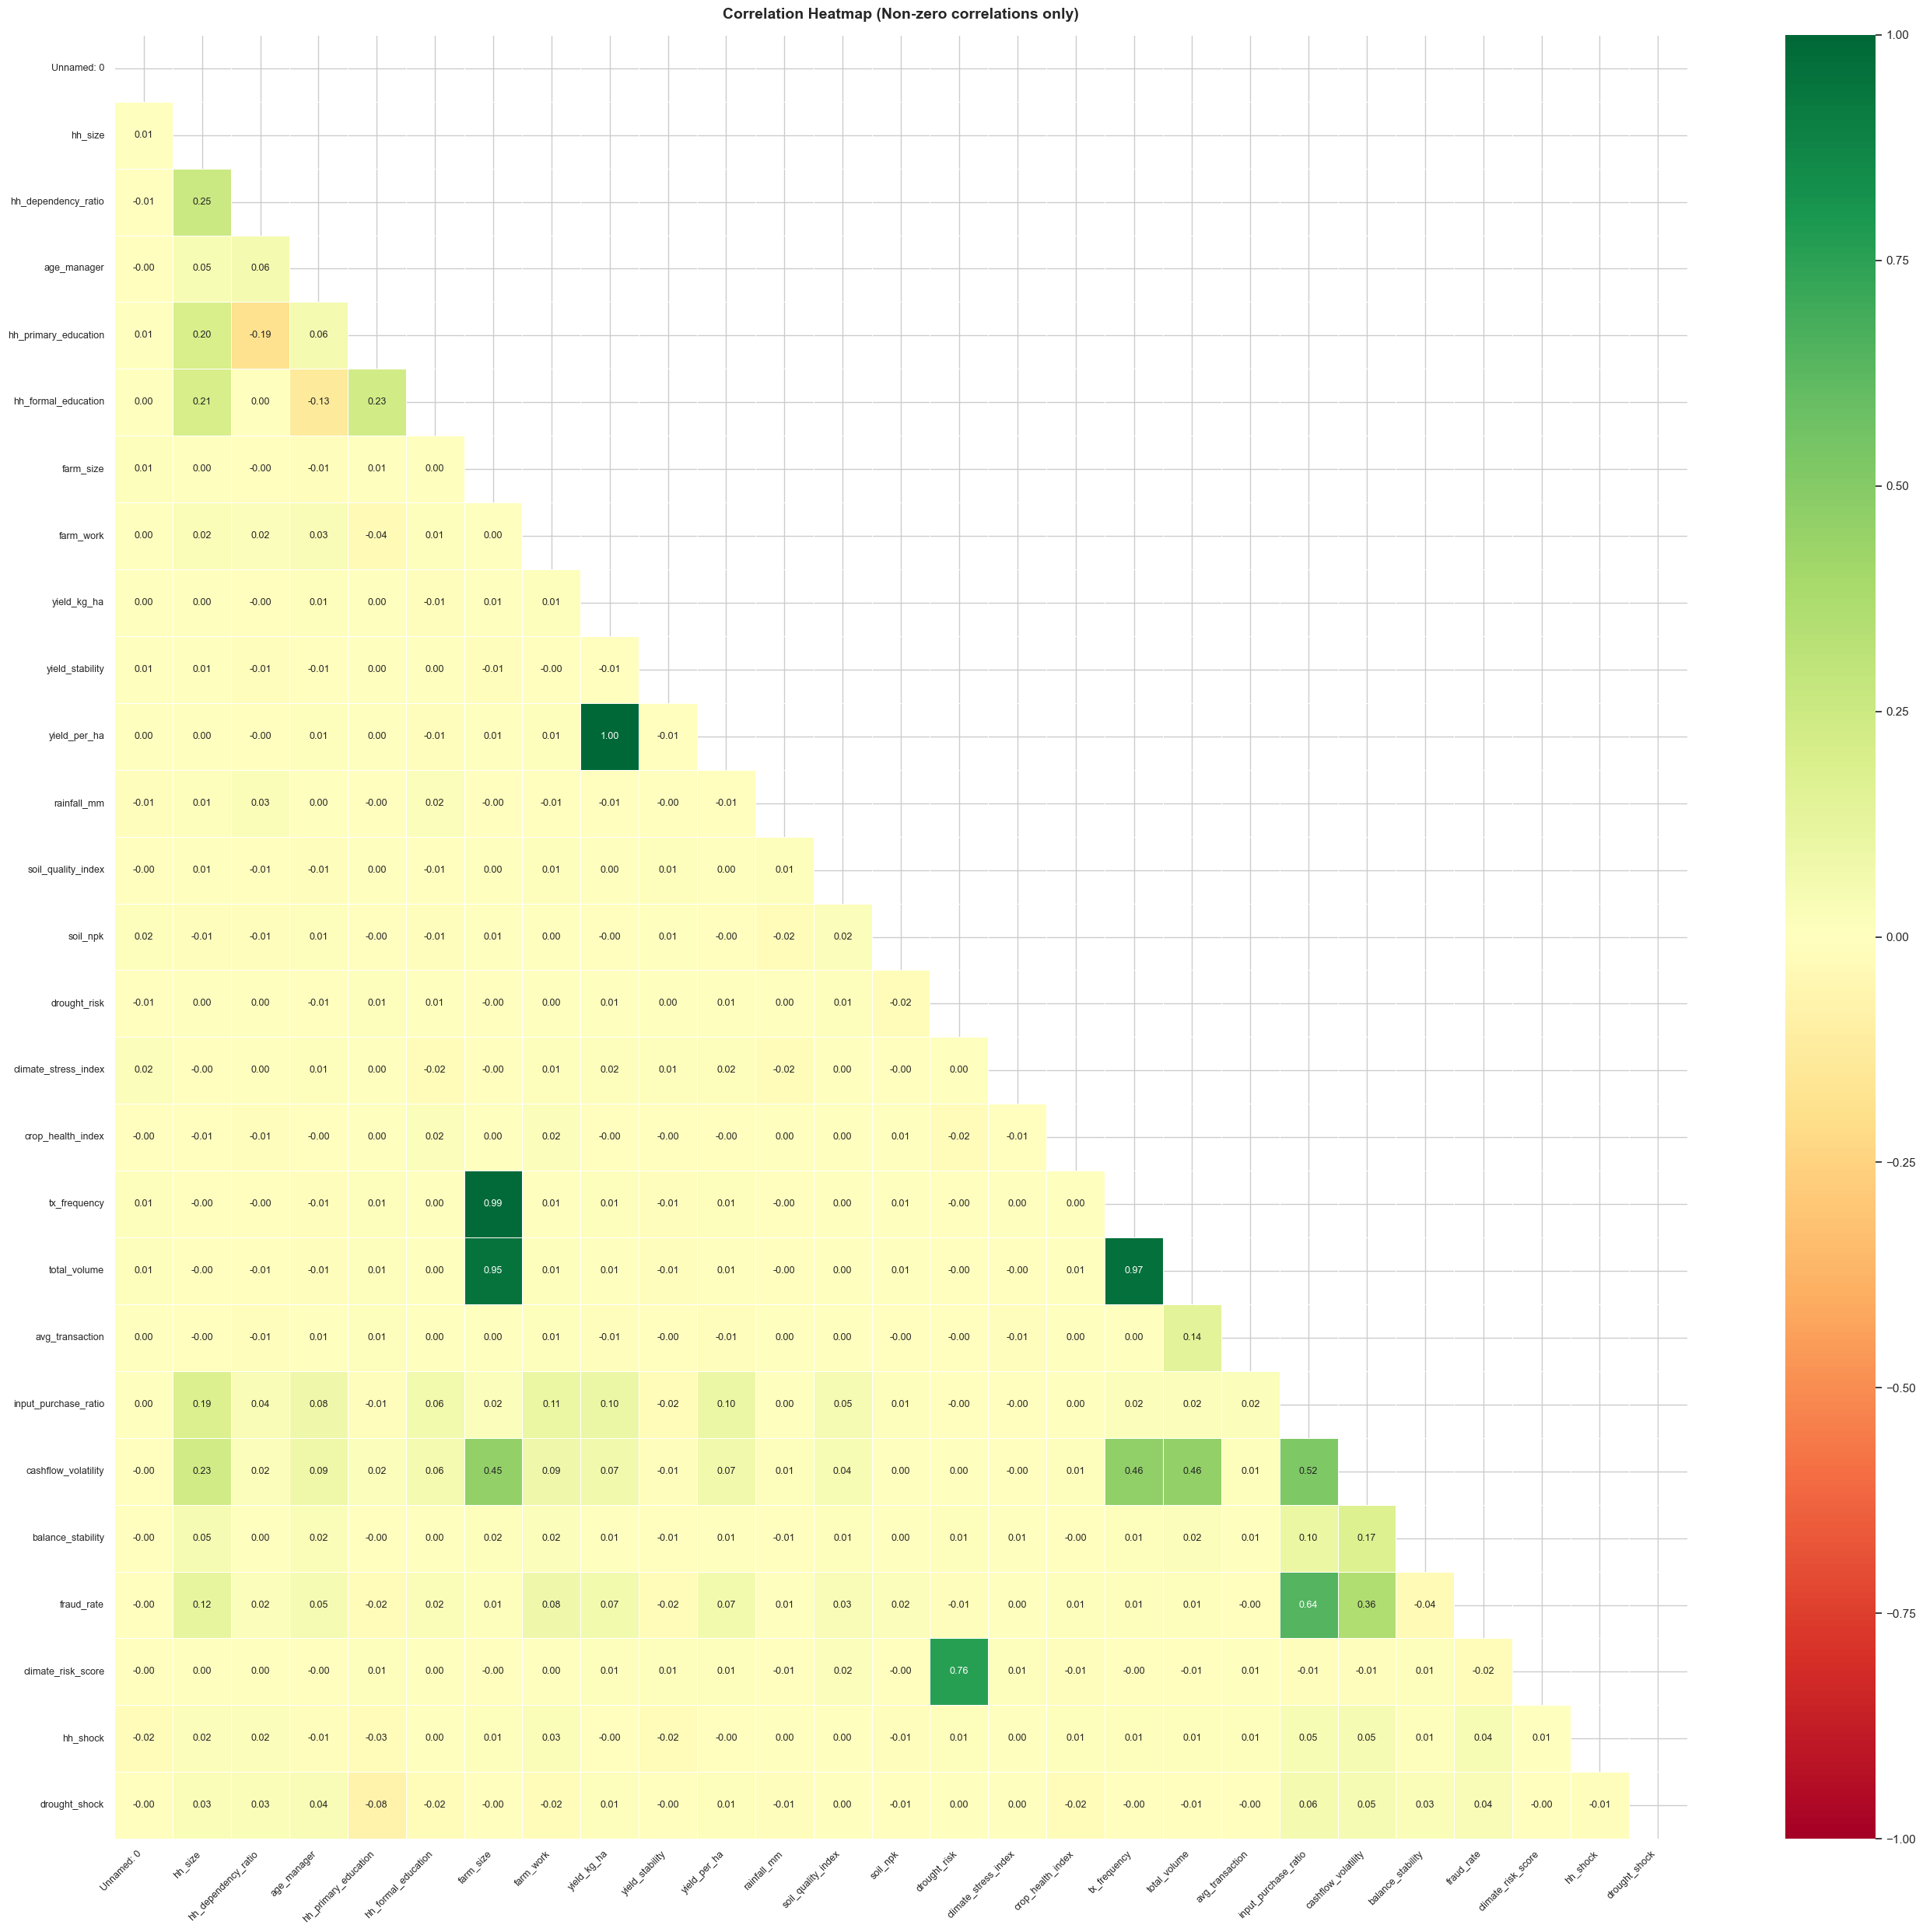

In [ ]:
# Correlation matrix 
core_num_cols = [c for c in num_cols if not c.startswith(('country_', 'main_crop_'))]
corr_matrix = final_data[core_num_cols].corr()

#  Remove zero-correlation values
filtered_corr = corr_matrix.copy()

# keep only non-zero correlations
filtered_corr = filtered_corr.where(np.abs(filtered_corr) > 0)

# drop rows/columns that are fully zero/NaN
filtered_corr = filtered_corr.dropna(axis=0, how='all').dropna(axis=1, how='all')

#  Plot heatmap
plt.figure(figsize=(max(10, len(filtered_corr.columns)), max(8, len(filtered_corr.columns) - 2)))

mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

sns.heatmap(
    filtered_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap (Non-zero correlations only)',
          fontweight='bold', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Outlier Detection

Box plots highlight outliers in key numerical features. Extreme outliers can distort model training and should be investigated.

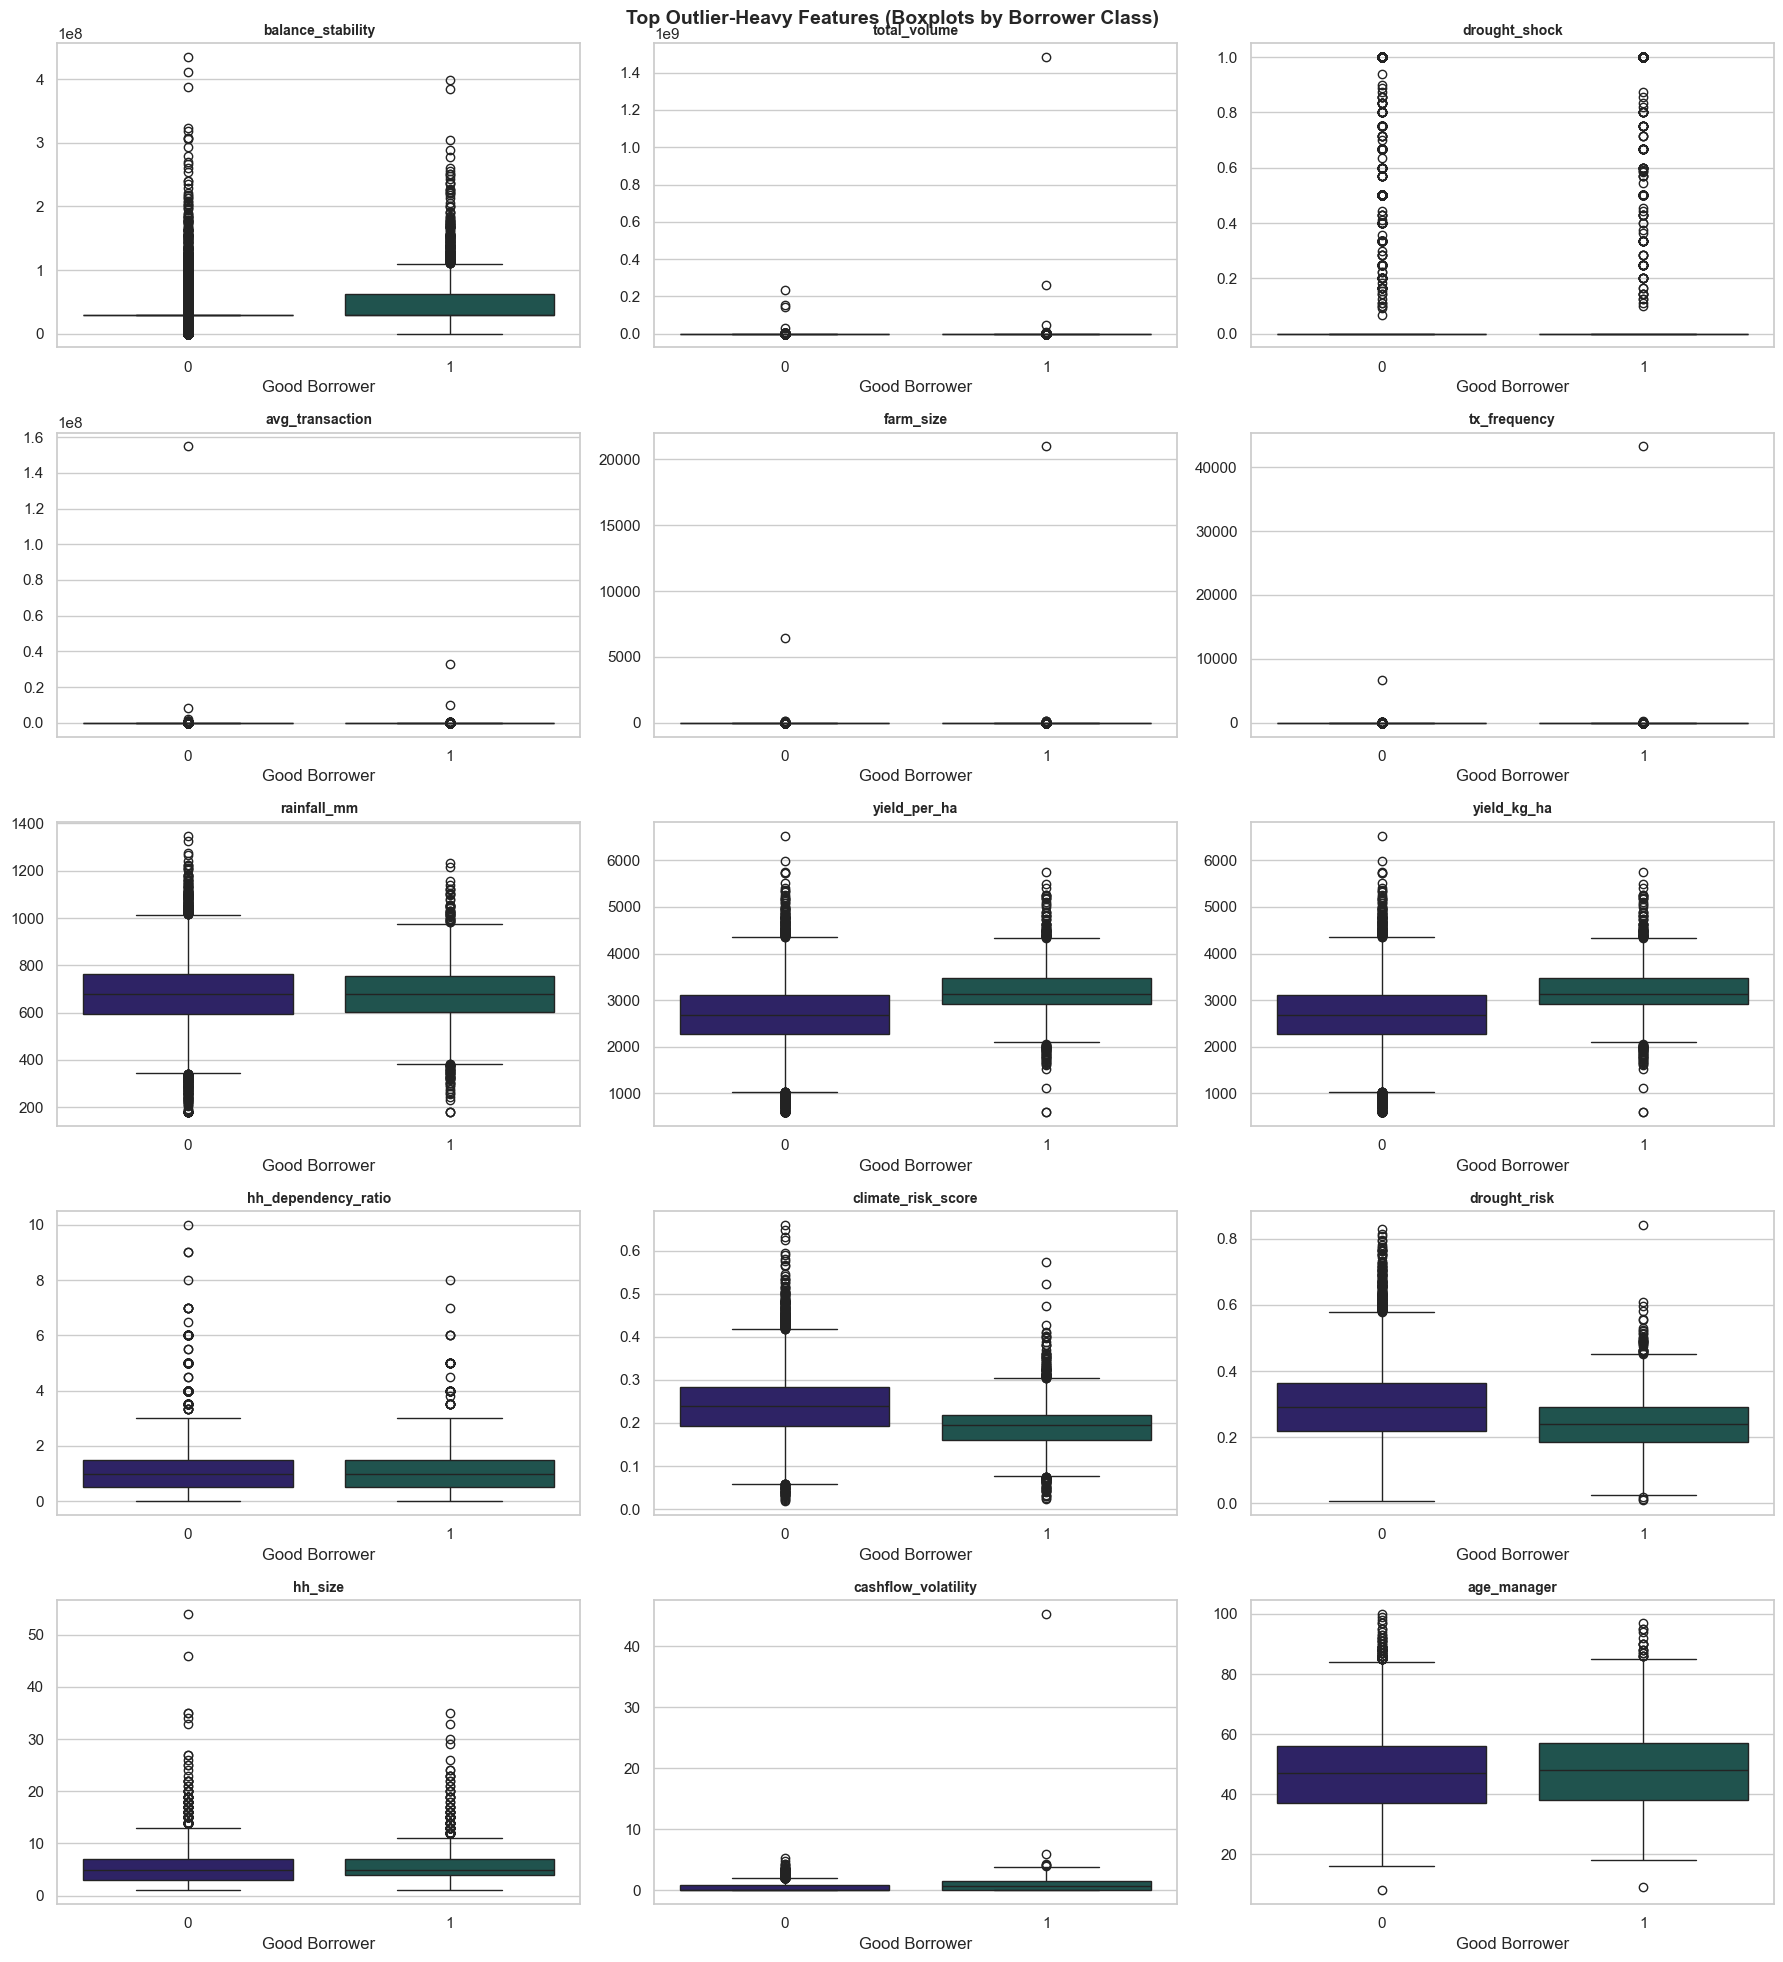

In [ ]:

#  Identify numerical features 
boxplot_cols = [c for c in core_num_cols 
                if c != 'good_borrower' and final_data[c].nunique() > 10]

#  Compute outlier counts (IQR method) 
outlier_counts = {}

for col in boxplot_cols:
    Q1 = final_data[col].quantile(0.25)
    Q3 = final_data[col].quantile(0.75)
    IQR = Q3 - Q1

    n_out = ((final_data[col] < Q1 - 1.5 * IQR) |
             (final_data[col] > Q3 + 1.5 * IQR)).sum()

    outlier_counts[col] = n_out

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['outlier_count'])
outlier_df = outlier_df.sort_values(by='outlier_count', ascending=False)

#  Select only top outlier-heavy features 
threshold = 100
selected_cols = outlier_df[outlier_df['outlier_count'] > threshold].index.tolist()

#  Grid size setup 
n_cols = 3
n_rows = int(np.ceil(len(selected_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

#  Plot 
for i, col in enumerate(selected_cols):
    sns.boxplot(x='good_borrower', y=final_data[col], data=final_data,
                palette=["#261870", "#175C55"], 
                ax=axes[i])

    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Good Borrower')
    axes[i].set_ylabel('')

# Hide empty plots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Outlier-Heavy Features (Boxplots by Borrower Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Relationships with Target Variable

KDE plots stratified by borrower class reveal whether a feature's distribution separates good from bad borrowers — a direct indicator of discriminative power.

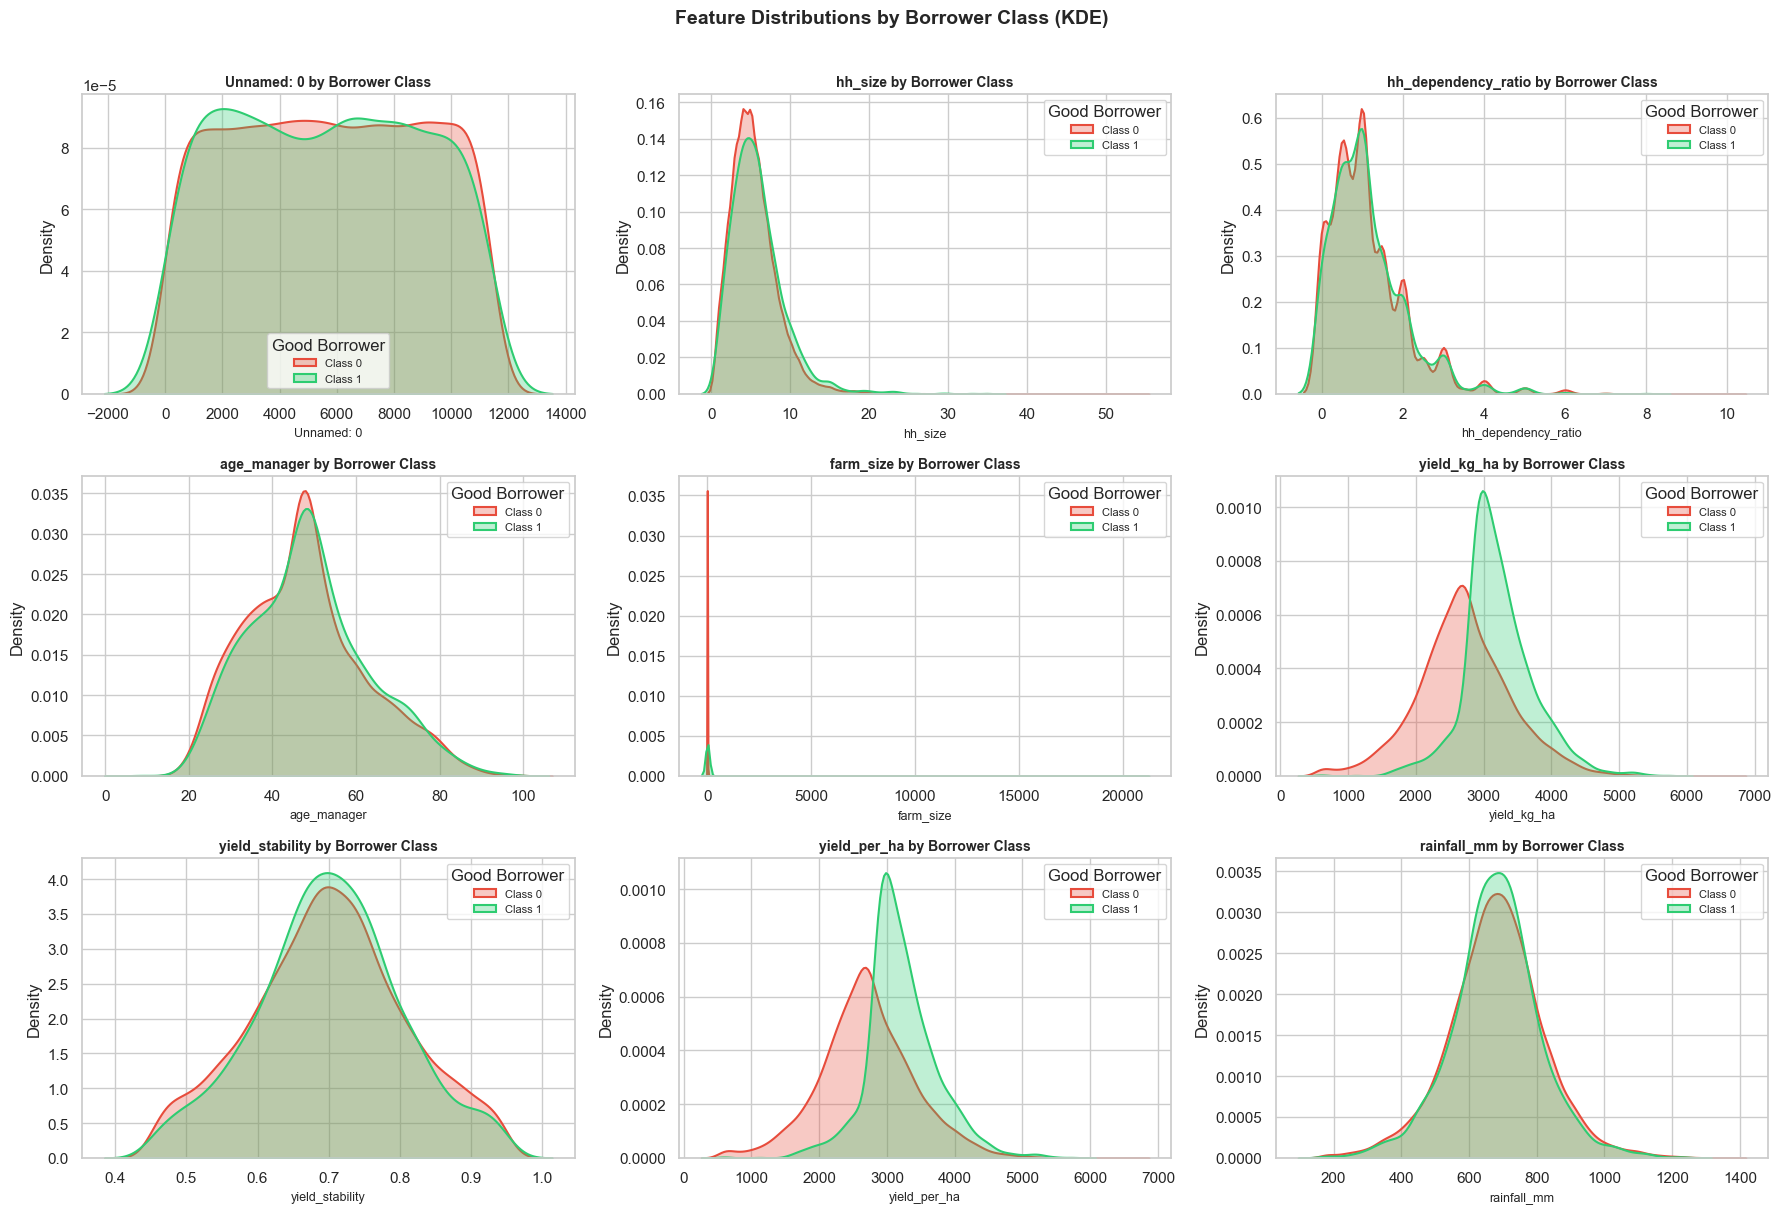

In [ ]:
# KDE by borrower class 
kde_cols = [c for c in boxplot_cols if c in final_data.columns][:9]  # max 9 for readability

if 'good_borrower' in final_data.columns and kde_cols:
    n_cols_kde = 3
    n_rows_kde = -(-len(kde_cols) // n_cols_kde)
    fig, axes = plt.subplots(n_rows_kde, n_cols_kde,
                             figsize=(6 * n_cols_kde, 4 * n_rows_kde))
    axes = axes.flatten()

    palette = {0: '#e74c3c', 1: '#2ecc71'}
    for idx, col in enumerate(kde_cols):
        ax = axes[idx]
        for cls in [0, 1]:
            subset = final_data[final_data['good_borrower'] == cls][col].dropna()
            sns.kdeplot(subset, ax=ax, label=f'Class {cls}',
                        color=palette[cls], fill=True, alpha=0.3, linewidth=1.5)
        ax.set_title(f'{col} by Borrower Class', fontweight='bold', fontsize=10)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Density')
        ax.legend(title='Good Borrower', fontsize=8)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions by Borrower Class (KDE)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

The KDE plots show that crop yield variables provide the strongest separation between good and bad borrowers, while household and environmental variables show heavy overlap. This suggests that productivity and financial performance are the main drivers of creditworthiness in this dataset.

## 10. Key EDA Insights & Implications for Modelling

| # | Observation | Implication |
|---|-------------|-------------|
| 1 | **Class imbalance** — the majority class (bad borrowers) significantly outnumbers good borrowers | SMOTE will to prevent the model from defaulting to the majority class |
| 2 | **Right-skewed distributions** — several financial and yield-related features exhibit positive skew | Tree-based models (XGBoost, LightGBM) handle skewed features natively; scaling is needed only for Logistic Regression |
| 3 | **Outliers detected** — financial transaction and yield features contain IQR-based outliers | Outliers will be handled |
| 4 | **Multicollinearity** — some environmental risk features are moderately correlated with each other | Feature selection will be done reduce redundancy; SHAP analysis downstream will confirm importance |
| 5 | **High cardinality categoricals** — `country` and `main_crop_clean` have many unique values | One-hot encoding is appropriate |

> **Conclusion:** The dataset is suitable for classification modelling. The main challenges are class imbalance and a few high-skew features, both of which are addressed in the preprocessing and model pipeline that follows.



# PREPROCESSING

### 1. Outlier Handling with Quantile Capping

To reduce the influence of extreme values in the dataset, a custom transformer called `OutlierCapper` was implemented. This transformer caps outliers using lower and upper quantile thresholds instead of removing observations.

The approach works by:

- Calculating the lower and upper quantiles for each numerical feature during the `fit()` stage
- Replacing values below the lower quantile with the lower bound
- Replacing values above the upper quantile with the upper bound

In this project:

- The lower bound is set at the **1st percentile (`0.01`)**
- The upper bound is set at the **99th percentile (`0.99`)**

This method helps:

- Reduce the effect of extreme outliers
- Preserve all observations in the dataset
- Improve model robustness and stability
- Maintain compatibility with Scikit-learn pipelines



In [ ]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.bounds_ = {}
        X = pd.DataFrame(X)

        for col in X.columns:
            self.bounds_[col] = (
                X[col].quantile(self.lower),
                X[col].quantile(self.upper)
            )
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            lower_bound, upper_bound = self.bounds_[col]
            X[col] = X[col].clip(lower_bound, upper_bound)

        return X.values

### 2. Log Transformation for Skewed Features

To address skewness in numerical variables, a custom transformer called `LogTransformer` was implemented. The transformer applies a logarithmic transformation to selected skewed features using the `log1p()` function.

The transformation helps normalize highly skewed distributions by compressing large values while preserving smaller ones.

This approach is preferred because it safely handles zero values in the dataset.

The transformer works by:

- Accepting a list of skewed numerical columns
- Applying logarithmic transformation only to the specified columns
- Leaving all other features unchanged

This preprocessing step helps:

- Reduce positive skewness
- Improve feature distribution
- Stabilize variance
- Enhance machine learning model performance



In [ ]:
class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols=None):
        self.skewed_cols = skewed_cols or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in self.skewed_cols:
            if col in X.columns:
                X[col] = np.log1p(X[col])

        return X.values

### Feature Selection and Variable Categorization

The dataset variables were grouped into categorical, numerical, and skewed features to support efficient preprocessing and model development.


In [ ]:
target = "good_borrower"

categorical_columns = [
    'country', 
    'main_crop_clean'
]

numerical_columns = [
    'hh_size', 'hh_dependency_ratio', 'age_manager',
    'farm_size', 'yield_kg_ha', 'yield_stability',
    'yield_per_ha', 'rainfall_mm', 'soil_quality_index',
    'soil_npk', 'drought_risk', 'climate_stress_index',
    'crop_health_index', 'tx_frequency', 'total_volume',
    'avg_transaction', 'input_purchase_ratio',
    'cashflow_volatility', 'balance_stability',
    'fraud_rate', 'climate_risk_score', 'drought_shock'

]

skewed_cols = [
    'avg_transaction',
    'total_volume',
    'tx_frequency',
    'farm_size'
]

### Functional Transformers for Feature Engineering

To streamline preprocessing and improve pipeline integration, Scikit-learn `FunctionTransformer` objects were used for logarithmic transformation and outlier capping.


In [ ]:
log_transform = FunctionTransformer(
    np.log1p,
    feature_names_out="one-to-one"
)


def cap_outliers(X):
    X = X.copy()
    lower = np.quantile(X, 0.01, axis=0)
    upper = np.quantile(X, 0.99, axis=0)
    return np.clip(X, lower, upper)

outlier_capper = FunctionTransformer(
    cap_outliers,
    feature_names_out="one-to-one"
)

### 3. Combined Preprocessing Pipeline

To ensure consistent and efficient data preparation, both numerical and categorical preprocessing pipelines were combined using Scikit-learn’s `ColumnTransformer`.

This approach allows different transformations to be applied to specific groups of features within a single unified preprocessing workflow.



#### Numerical Feature Processing

The numerical pipeline performs the following operations:

1. **Median Imputation**
   - Replaces missing numerical values using the median.

2. **Log Transformation**
   - Applies logarithmic transformation to reduce skewness and stabilize variance.

3. **Outlier Capping**
   - Caps extreme values using the 1st and 99th percentile thresholds.

4. **Feature Scaling**
   - Standardizes numerical variables using `StandardScaler`.



#### Categorical Feature Processing

The categorical pipeline performs:

1. **Most Frequent Imputation**
   - Replaces missing categorical values with the most common category.

2. **One-Hot Encoding**
   - Converts categorical variables into binary encoded features.
   - Handles unseen categories safely during prediction.



In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", log_transform),
    ("outlier_cap", outlier_capper),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

### 4. Defining Features and Target Variable

The dataset was divided into:

- **Features (`X`)** — all predictor variables used for training the model
- **Target (`y`)** — the output variable representing borrower classification

The target variable selected for prediction is:

- `good_borrower`



In [ ]:
X = final_data.drop('good_borrower', axis=1)

y = final_data['good_borrower']

### 5. Splitting the Dataset

The dataset is split into training and testing sets using an 80/20 ratio.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6. Applying the Preprocessing Pipeline

The preprocessing pipeline was fitted on the training data and then applied to both the training and testing datasets.

- `fit_transform()` was used on the training set to learn preprocessing parameters and transform the data.
- `transform()` was used on the testing set to ensure consistent preprocessing without data leakage.


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
feature_names = preprocessor.get_feature_names_out()

In [ ]:
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

### 7. Handling Class Imbalance Using SMOTE

To address the imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data. SMOTE generates synthetic examples of the minority class (good borrowers) to create a balanced dataset. This helps the model learn patterns from both classes more effectively and improves its ability to correctly identify good borrowers.

In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train)

#### Check new class balance

<Axes: xlabel='good_borrower'>

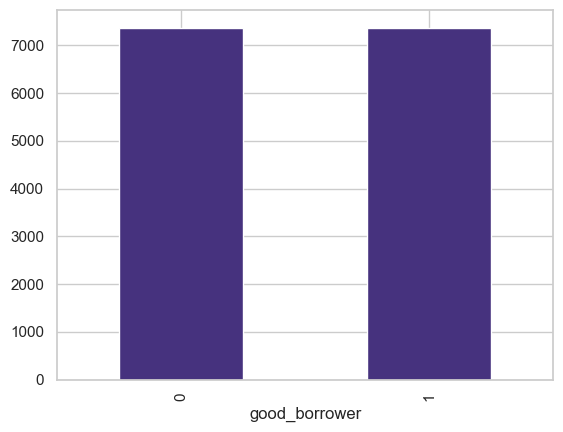

In [ ]:
y_train_resampled.value_counts().plot(kind='bar')

# 2. MODELLING
## 1. Logistic Regression- Baseline
A simple baseline model is used as the starting point for the AgriScore credit scoring system. The purpose of a baseline model is not to achieve the highest accuracy, but to establish a reference performance level that future models can be compared against.

Logistic Regression is used as the primary baseline model because:

It is simple, fast, and easy to interpret
It provides probabilistic outputs (useful for credit risk scoring)
It assumes a linear relationship between features and the target variable
It works well as a first benchmark in classification problems
In the context of AgriScore, Logistic Regression helps us understand how individual factors such as yield, stability, and household characteristics contribute to the likelihood of a farmer being creditworthy.

### 1. Training the Logistic Regression Model

In this step, we train a Logistic Regression model on the training data.


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 2. Making Predictions

After training the model, we use it to predict borrower status on the test dataset.

The output `y_pred` represents the model's predicted classification:
- 1 → Good borrower  
- 0 → Bad borrower  

These predictions will be compared with actual values for evaluation.

In [ ]:
y_pred = model.predict(X_test_processed)

### 3. Model Evaluation

We evaluate the model using standard classification metrics:

- **Accuracy Score** → Overall performance of the model  
- **Classification Report** → Includes precision, recall, and F1-score  

These metrics help us understand how well the model is performing in identifying good and bad borrowers.

Accuracy: 0.7879053461875548
              precision    recall  f1-score   support

           0       0.94      0.78      0.86      1843
           1       0.47      0.81      0.59       439

    accuracy                           0.79      2282
   macro avg       0.71      0.79      0.73      2282
weighted avg       0.85      0.79      0.81      2282



<Axes: >

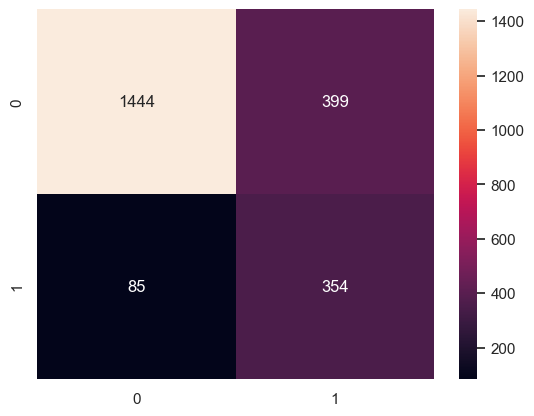

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

### 4. Model Performance Interpretation (Logistic Regression)
The model shows a moderate overall performance with an accuracy of about 79% (specifically 78.79%). However, this performance is influenced by class imbalance in the dataset, where Class 0 has significantly more samples (1,843) compared to Class 1 (439).

The model performs well in identifying Class 0 (majority class), achieving a high precision of 94%, meaning it is highly reliable when predicting this class. However, its recall is 78%, meaning it still misses a portion of actual Class 0 cases, indicating some misclassification.

For Class 1 (minority class), the model achieves a recall of 81%, meaning it correctly identifies the vast majority of the actual positive cases. However, the precision for Class 1 is low (47%), showing that more than half of the predictions for Class 1 are incorrect.

Overall, the model tends to generate a notable number of false positives, misclassifying Class 0 as Class 1 (399 cases), alongside 85 false negatives where Class 1 was missed. This indicates a trade-off where the model is highly sensitive to detecting Class 1 but at the cost of reduced reliability (precision) when making those predictions.

##  2. Decision Tree Model 

In this step, a Decision Tree Classifier is trained using the resampled training data to handle class imbalance. The model learns decision rules from the features to classify farmers as either good or bad borrowers. After training, predictions are made on the test set and the model is evaluated using accuracy and a classification report to assess its performance across both classes.

In [ ]:


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_processed)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8146362839614374
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1843
           1       0.52      0.61      0.56       439

    accuracy                           0.81      2282
   macro avg       0.71      0.74      0.72      2282
weighted avg       0.83      0.81      0.82      2282



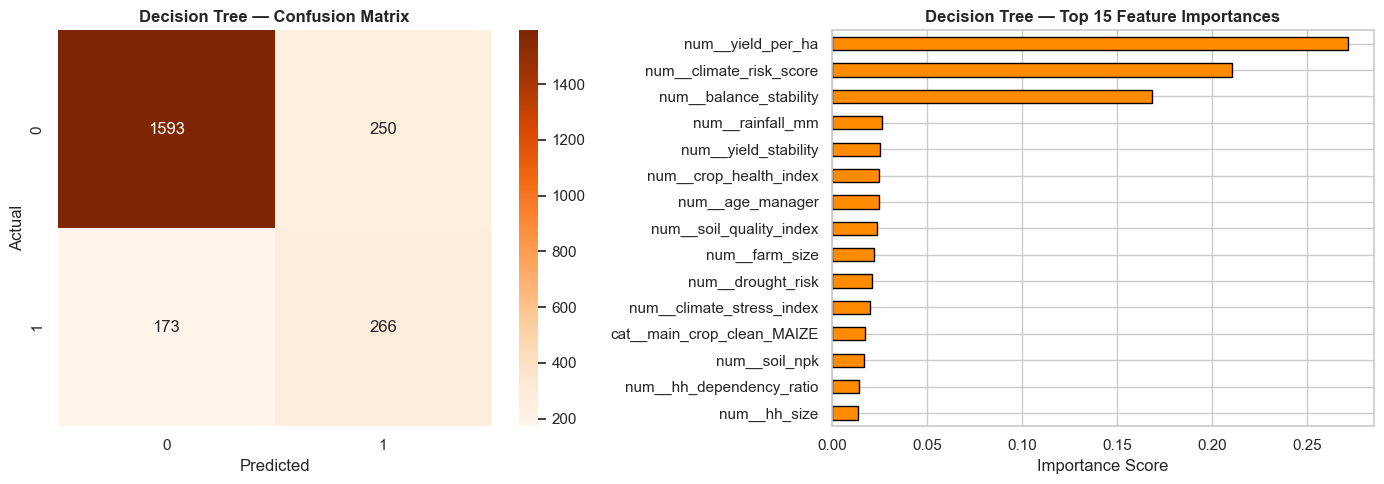

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a temporary copy of X_test and rename 'Unnamed0' to 'Unnamed: 0' for Decision Tree prediction
# Convert to DataFrame using correct feature names
X_test_dt_compatible = pd.DataFrame(
    X_test_processed)
#     columns=feature_names  # from preprocessor.get_feature_names_out()
# )

# # Now safe to use .columns
# if 'Unnamed0' in X_test_dt_compatible.columns:
#     X_test_dt_compatible = X_test_dt_compatible.rename(
#         columns={'Unnamed0': 'Unnamed: 0'}
#     )

# Get predictions from Decision Tree
y_pred_dt = dt_model.predict(X_test_dt_compatible)

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('Decision Tree — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
importances_dt = pd.Series(dt_model.feature_importances_,
                         index=preprocessor.get_feature_names_out()).sort_values(ascending=False).head(15)
importances_dt.sort_values().plot(kind='barh', ax=axes[1],
                                color='darkorange', edgecolor='k')
axes[1].set_title('Decision Tree — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Model Performance Interpretation (Decision Tree)
The Decision Tree model achieved an accuracy of 81.5%, showing a solid ability to classify the data. It performs strongly on Class 0 (majority class), with high precision (0.90) and good recall (0.86), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows weaker performance, with precision of 0.52 and recall of 0.61. This indicates that while it can detect some Class 1 cases, it still misses many and also produces a fair number of incorrect predictions.

Overall, the model is better at predicting Class 0 than Class 1, showing a bias toward the majority class. While performance is reasonable, there is still room for improvement in identifying the minority class more effectively.

## 3. Random Forest Model- Advanced

In this step, a Random Forest Classifier is trained using the resampled training data. The model builds multiple decision trees and combines their outputs to make more accurate and stable predictions. After training, predictions are made on the test set and evaluated using accuracy and a classification report to measure performance across both classes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_processed)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8523225241016652
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1843
           1       0.59      0.74      0.66       439

    accuracy                           0.85      2282
   macro avg       0.76      0.81      0.78      2282
weighted avg       0.87      0.85      0.86      2282



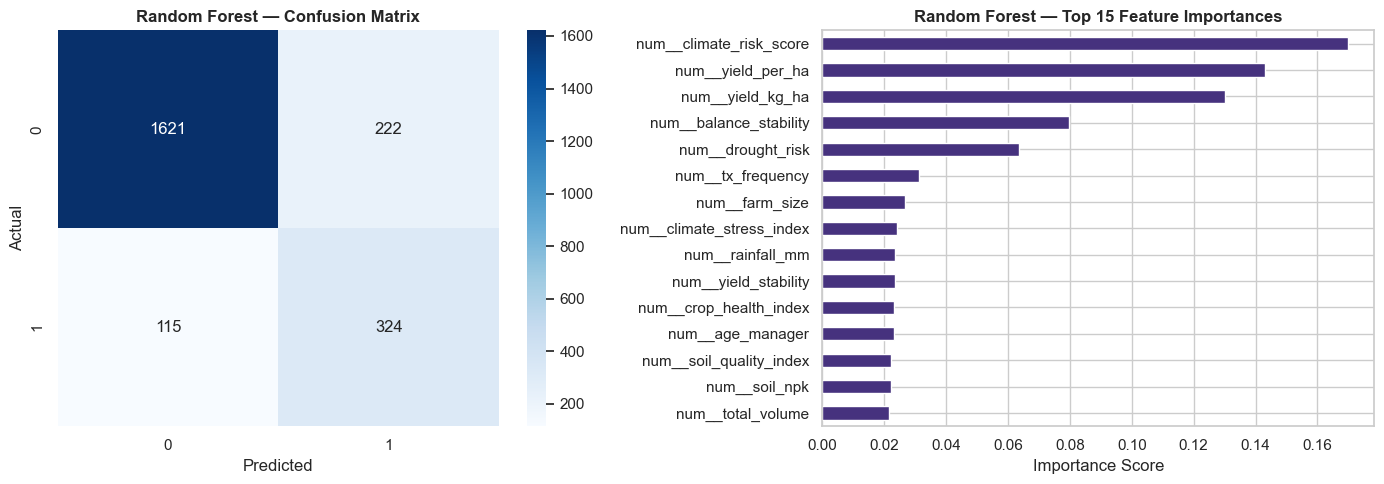

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a temporary copy of X_test and rename 'Unnamed0' to 'Unnamed: 0' for Random Forest prediction
X_test_rf_compatible = X_test_processed.copy()
# if 'Unnamed0' in X_test_rf_compatible.columns:
    # X_test_rf_compatible = X_test_rf_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})

# Get predictions from Random Forest
y_pred_rf = rf_model.predict(X_test_rf_compatible)

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
# Use X_train.columns because rf_model was trained on X_train_resampled derived from X_train

feature_names = preprocessor.get_feature_names_out()

importances_rf = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

importances_rf.sort_values().plot(kind='barh')

axes[1].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Model Performance Interpretation (Random Forest)
The Random Forest model achieved an accuracy of 85.2%, showing improved performance compared to the previous models. It performs strongly on Class 0 (majority class), with high precision (0.93) and good recall (0.88), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows moderate performance, with a precision of 0.59 and a solid recall of 0.74. This indicates that while it successfully detects a large majority of the Class 1 cases, it still produces a fair number of incorrect positive predictions.

Overall, the model provides a better balance between both classes compared to previous models, notably reducing the number of false predictions (222 false positives and 115 false negatives) and improving overall predictive reliability.

## 4. XGBoost Model

In this step, an XGBoost Classifier is trained using the resampled training data to improve predictive performance. XGBoost is a powerful boosting algorithm that builds trees sequentially to correct previous errors and capture complex patterns in the data.

After training, the model is used to make predictions on the test set, and performance is evaluated using accuracy and a classification report to assess how well it performs across both classes.

In [ ]:
# Ensure column names are standardized for XGBoost training and prediction.
# This step accounts for potential renaming that might occur elsewhere
# and ensures the model is trained with consistent feature names.

# Convert back to DataFrame (after SMOTE)
X_train_resampled = pd.DataFrame(X_train_resampled)
X_test = pd.DataFrame(X_test)

# Clean column names safely
X_train_resampled.columns = X_train_resampled.columns.astype(str).str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.astype(str).str.replace('[^A-Za-z0-9_]+', '', regex=True)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_processed)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8470639789658194
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1843
           1       0.59      0.65      0.62       439

    accuracy                           0.85      2282
   macro avg       0.75      0.77      0.76      2282
weighted avg       0.85      0.85      0.85      2282



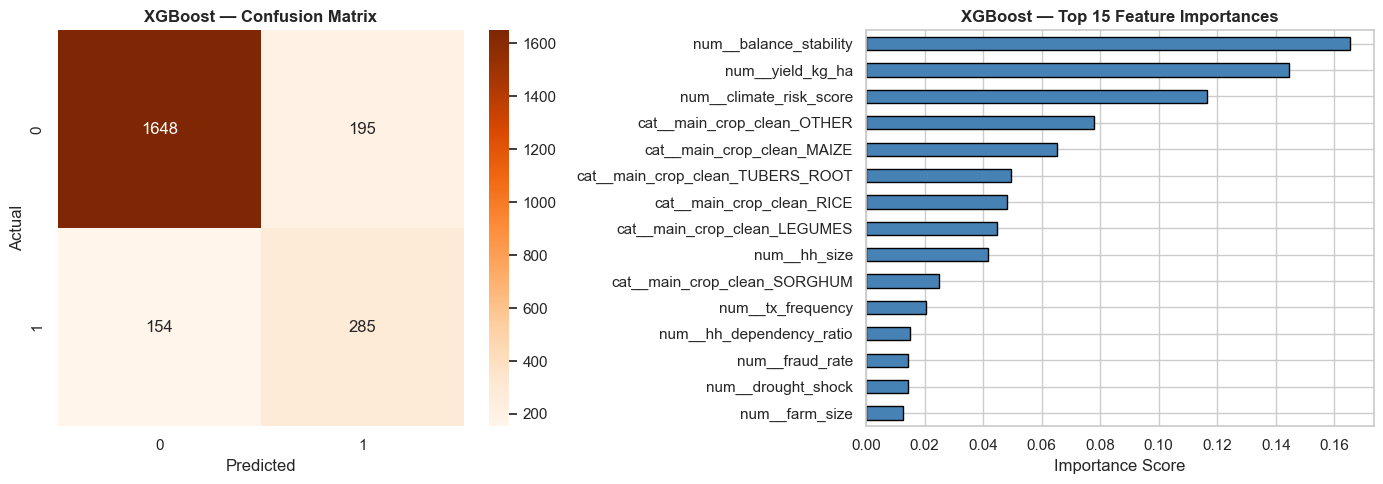

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get predictions from the XGBoost model
y_pred_xgb = xgb_model.predict(X_test_processed)

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0', '1'], # Use generic labels as label_encoder is not for this target
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
importances = pd.Series(xgb_model.feature_importances_,
                        index=X_train_resampled.columns).sort_values(ascending=False).head(15)
importances.sort_values().plot(kind='barh', ax=axes[1],
                               color='steelblue', edgecolor='k')
axes[1].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Model Performance Interpretation (XGBoost)
The XGBoost model achieved an accuracy of 84.7%, showing strong overall performance. It performs very well on Class 0 (majority class), with high precision (0.91) and recall (0.89), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.59 and recall of 0.65. This indicates that while it correctly identifies a solid portion of Class 1 cases, it still misses some and produces a fair number of incorrect predictions.

Overall, XGBoost provides a balanced improvement over previous models, especially in terms of stability and precision for the minority class, but there is still room for improving recall for better class identification.

In [ ]:
# pip install lightgbm


In [ ]:
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train_resampled, y_train_resampled)

y_pred_lgbm = lgbm_model.predict(X_test_processed)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 7372, number of negative: 7372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7190
[LightGBM] [Info] Number of data points in the train set: 14744, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Accuracy: 0.8409290096406661
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1843
           1       0.58      0.65      0.61       439

    accuracy                           0.84      2282
   macro avg       0.75      0.77      0.76      2282
weighted avg       0.85      0.84      0.84      2282



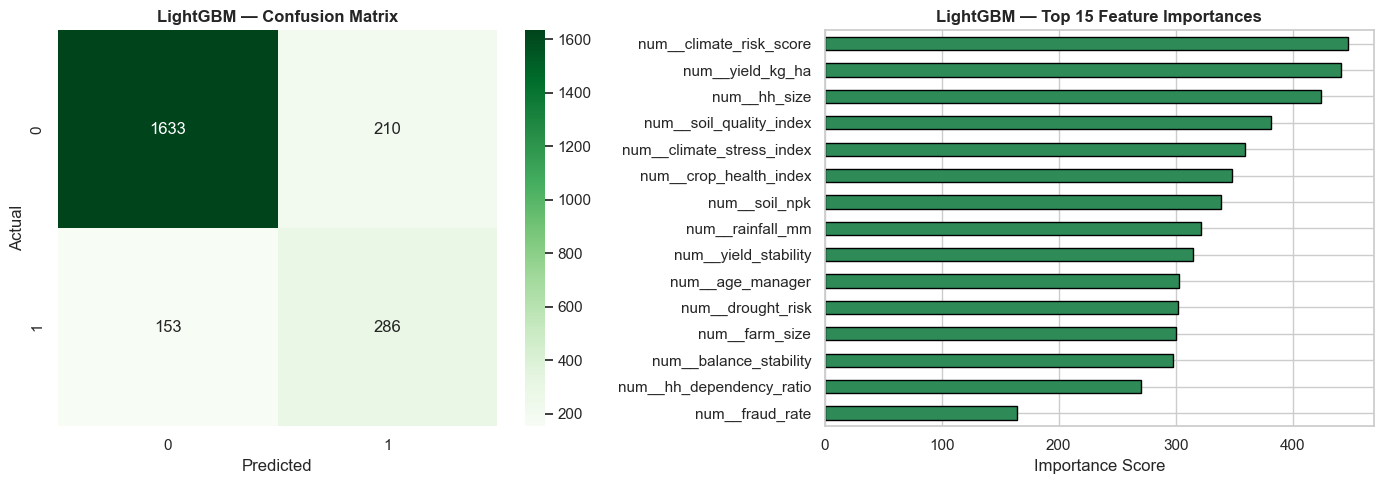

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get predictions from the LightGBM model
y_pred_lgb = lgbm_model.predict(X_test_processed)

# Confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('LightGBM — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
feature_names = preprocessor.get_feature_names_out()

importances_lgb = pd.Series(
    lgbm_model.feature_importances_,
    index=feature_names).sort_values(ascending=False).head(15)
importances_lgb.sort_values().plot(kind='barh', ax=axes[1],
                                 color='seagreen', edgecolor='k')
axes[1].set_title('LightGBM — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Model Performance Interpretation (LightGBM)
The LightGBM model achieved an accuracy of 84.0%, showing strong overall performance. It performs very well on Class 0 (majority class), with high precision (0.91) and recall (0.89), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.58 and recall of 0.65. This indicates that while it correctly identifies a solid portion of Class 1 cases, it still misses some and produces a fair number of incorrect predictions.

Overall, LightGBM provides a balanced improvement over previous models, especially in terms of stability and precision for the minority class, but there is still room for improving recall for better class identification.

# MODEL EVALUATION
the LightGBM model was chosen as the final model for prediction and deployment due to its strong generalization capability and balanced classification performance.
Based on the evaluation metrics, LightGBM was selected as the best-performing model because it achieved:

* The highest Accuracy
* The highest F1-Score
* The highest AUC-ROC score

In [ ]:

# 1. STANDARDIZE COLUMN NAMES 
X_train_processed.columns = X_train_processed.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test_processed.columns = X_test_processed.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)


# 2. MODELS DICTIONARY 
models = {
    'Logistic Regression': model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,

    # Baseline LightGBM
    'LightGBM': lgbm_model,

}

# 3. EVALUATION LOOP

evaluation_results = []

for name, model_obj in models.items():

    X_test_compatible = X_test_processed.copy()

    # Predictions
    y_pred = model_obj.predict(X_test_compatible)

    # Probabilities for AUC
    if hasattr(model_obj, "predict_proba"):
        y_prob = model_obj.predict_proba(X_test_compatible)[:, 1]
    else:
        y_prob = y_pred

    # Metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }

    evaluation_results.append(metrics)


# 4. RESULTS TABLE

df_eval = pd.DataFrame(evaluation_results).set_index('Model')
df_eval_sorted = df_eval.sort_values(by='F1-Score', ascending=False)

print("=================== MODEL EVALUATION METRICS ===================")
print(df_eval_sorted.round(3).to_string())
print("================================================================")

=================== MODEL EVALUATION METRICS ===================
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Random Forest           0.852      0.593   0.738     0.658    0.911
XGBoost                 0.847      0.594   0.649     0.620    0.905
LightGBM                0.841      0.577   0.651     0.612    0.908
Logistic Regression     0.788      0.470   0.806     0.594    0.866
Decision Tree           0.815      0.516   0.606     0.557    0.735


NameError: name 'precision_recall_curve' is not defined

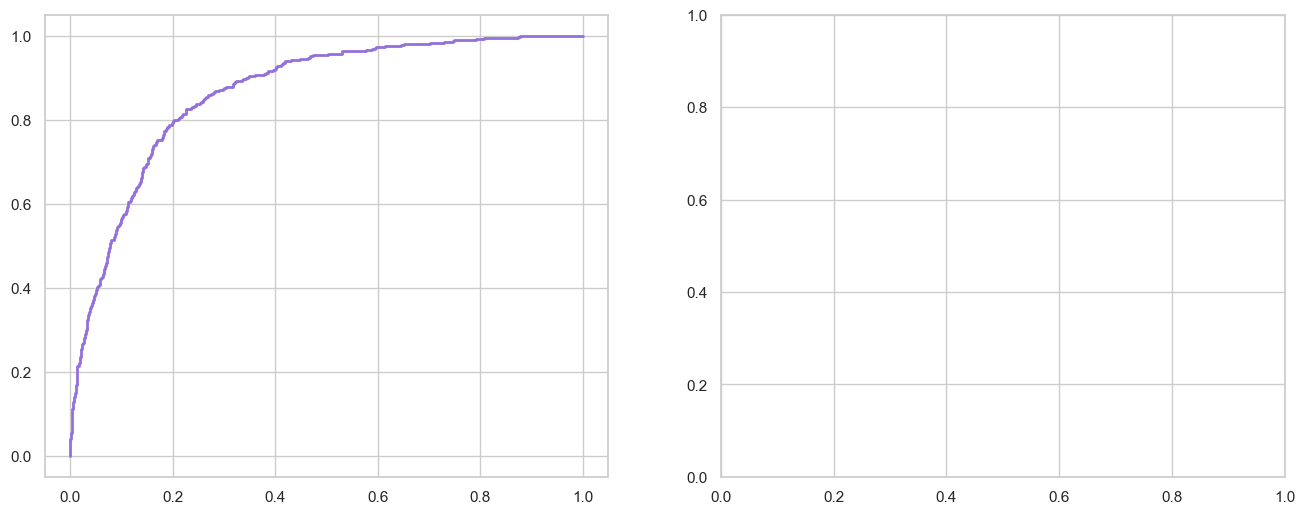

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# COLORS
colors = {
    'Logistic Regression': 'mediumpurple',
    'Decision Tree': 'darkorange',
    'Random Forest': 'dodgerblue',
    'XGBoost': 'crimson',
    'LightGBM': 'seagreen',
    
}
# LOOP THROUGH MODELS

for name, model_obj in models.items():

    X_test_compatible = X_test_processed.copy()

    # --- optional column alignment (kept from your logic) ---
    if name in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
        if 'Unnamed0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})

    elif name in ['XGBoost', 'LightGBM (Baseline)', 'LightGBM (Tuned)']:
        if 'Unnamed: 0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed: 0': 'Unnamed0'})

    
    # PROBABILITIES
    
    if hasattr(model_obj, "predict_proba"):
        y_prob = model_obj.predict_proba(X_test_compatible)[:, 1]
    else:
        y_prob = model_obj.predict(X_test_compatible)

    
    # ROC CURVE
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(
        fpr, tpr,
        label=f"{name} (AUC = {df_eval.loc[name, 'AUC-ROC']:.3f})",
        color=colors.get(name, 'gray'),
        lw=2
    )

    
    # PRECISION-RECALL CURVE
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(
        recall, precision,
        label=f"{name} (F1 = {df_eval.loc[name, 'F1-Score']:.3f})",
        color=colors.get(name, 'gray'),
        lw=2
    )


# ROC PLOT FORMATTING

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=13)
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)


# PR PLOT FORMATTING

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[1].legend(loc="lower left", frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

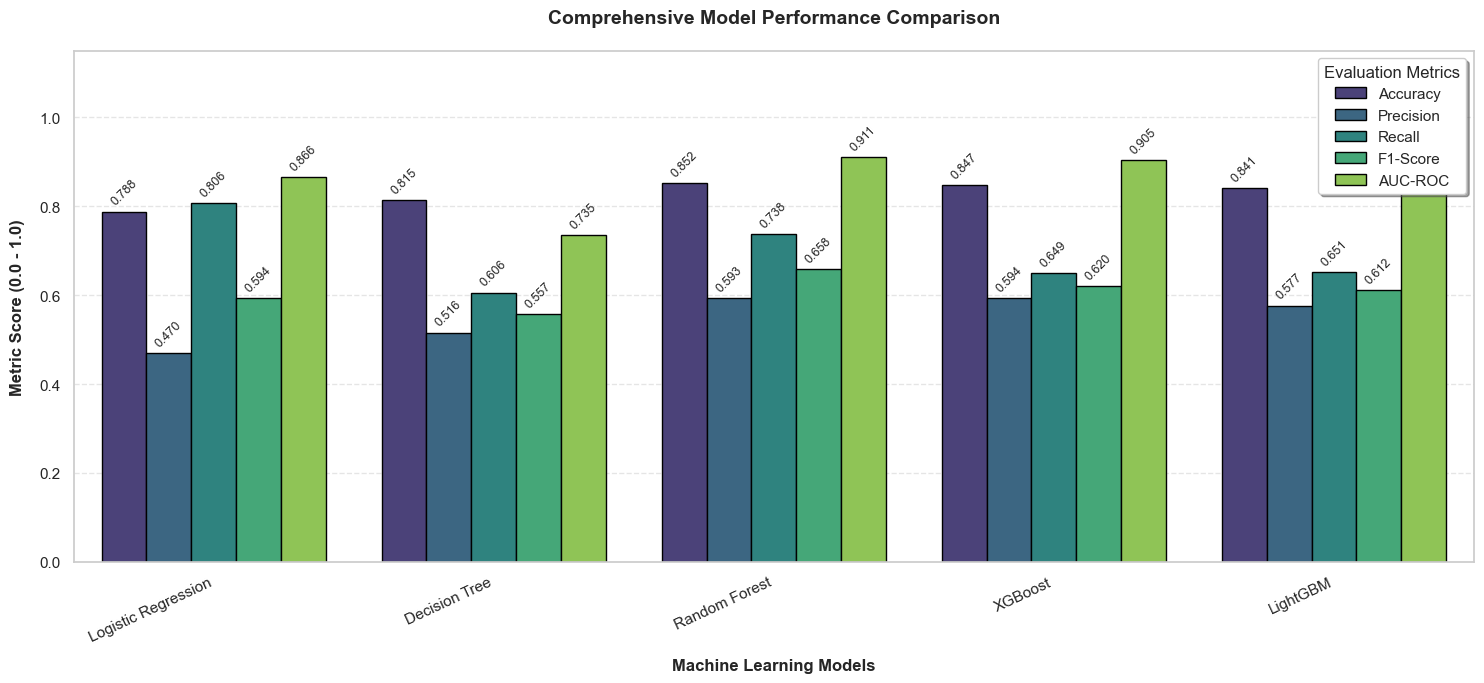

In [ ]:
# PREP DATA FOR PLOTTING
df_plot = df_eval.reset_index().melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)
# FIGURE SETUP

plt.figure(figsize=(15, 7))
# BAR PLOT

ax = sns.barplot(
    data=df_plot,
    x='Model',
    y='Score',
    hue='Metric',
    palette='viridis',
    edgecolor='black'
)
# VALUE LABELS

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, rotation=45)

# STYLING

plt.title(
    'Comprehensive Model Performance Comparison',
    fontweight='bold',
    fontsize=14,
    pad=20
)

plt.xlabel('Machine Learning Models', fontweight='bold', fontsize=12, labelpad=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontweight='bold', fontsize=12, labelpad=10)

plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(
    title='Evaluation Metrics',
    loc='upper right',
    frameon=True,
    shadow=True
)

plt.xticks(rotation=25, ha='right')  # 👈 improves readability with more models

plt.tight_layout()
plt.show()

## Tuned Random Forest Model

This section implements a hyperparameter-tuned Random Forest classifier using RandomizedSearchCV to optimize model performance.

In [ ]:
# PARAMETER GRID

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
# BASE MODEL

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
# CROSS-VALIDATION SETUP

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# RANDOM SEARCH

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)
# TRAIN TUNED MODEL

rf_search.fit(X_train_resampled, y_train_resampled)

best_rf = rf_search.best_estimator_

# PREDICTIONS

y_pred_rf = best_rf.predict(X_test_processed)
y_prob_rf = best_rf.predict_proba(X_test_processed)[:, 1]


# EVALUATION
print("========= TUNED RANDOM FOREST RESULTS =========")

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_rf), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
========= TUNED RANDOM FOREST RESULTS =========
Accuracy: 0.8479
Precision: 0.5987
Recall: 0.6355
F1-Score: 0.6166
AUC-ROC: 0.9071

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1843
           1       0.60      0.64      0.62       439

    accuracy                           0.85      2282
   macro avg       0.76      0.77      0.76      2282
weighted avg       0.85      0.85      0.85      2282



### Model performanced- Tuned Random Forest

- The model achieves good overall accuracy (0.85), meaning it correctly predicts most cases.
- The AUC-ROC is very high (0.9071), showing strong ability to distinguish between the two classes.
- However, the F1-score for class 1 is low (0.62), meaning performance on the minority class is only moderate.
- Precision (0.60) indicates a noticeable number of false positives for class 1.
- Recall (0.64) shows the model is missing some actual positive cases.
- The dataset is imbalanced (1843 vs 439), which explains why weighted averages look strong while minority class performance is weaker.

Overall, the model is good at ranking predictions (high AUC) but less reliable for correctly capturing the minority class in practice.

# LightGBM Model - Hyperparameter Tuning 
* tuning was performed to increase prediction accuracy, improve generalization, and reduce overfitting.

## Cross-Validation Setup
- **Method**: Stratified K-Fold Cross Validation
- **Number of Folds**:
- **Search Method**: RandomizedSearchCV
- **Iterations**: 20
- **Scoring Metric**: `f1_macro`



In [ ]:
from sklearn.model_selection import StratifiedKFold

lgb_param_dist = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [3, 4, 5, 6, -1],   # -1 = no limit
    'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'     : [15, 31, 63],         # key LightGBM param
    'subsample'      : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30],       # prevents tiny leaf overfitting
    'reg_alpha'      : [0, 0.1, 0.5],       # L1
    'reg_lambda'     : [0, 0.1, 0.5],       # L2
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    num_class=1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

# Clean column names for LightGBM compatibility
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

lgb_search.fit(X_train_resampled, y_train_resampled)
lgb_pred_prob = lgb_search.predict_proba(X_test_processed)[:, 1]



Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
lgb_pred = lgb_search.predict(X_test_processed)
lgb_pred_prob = lgb_search.predict_proba(X_test_processed)[:, 1]

print("LightGBM Accuracy:", round(accuracy_score(y_test, lgb_pred), 4))
print("LightGBM AUC-ROC:", round(roc_auc_score(y_test, lgb_pred_prob), 4))

print(classification_report(y_test, lgb_pred))
print(confusion_matrix(y_test, lgb_pred))

LightGBM Accuracy: 0.8541
LightGBM AUC-ROC: 0.9104
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1843
           1       0.60      0.70      0.65       439

    accuracy                           0.85      2282
   macro avg       0.76      0.80      0.78      2282
weighted avg       0.86      0.85      0.86      2282

[[1641  202]
 [ 131  308]]


## Tuned LightGBM Model Results

### Model Setup
We used **LightGBM (LGBMClassifier)** with hyperparameter tuning via **RandomizedSearchCV**.
- Cross-validation: **StratifiedKFold (3 splits)**
- Scoring metric: **F1 Macro** (balances performance across both classes)
- Parameters tuned: number of estimators, max depth, learning rate, number of leaves, subsample, colsample_bytree, min_child_samples, and regularization terms.

### Performance Metrics
- AUC-ROC: 0.91 → The model has excellent discriminatory power between positive and negative classes.

- Accuracy: 0.85 → Overall, 85% of predictions were correct.

- Precision (Class 0): 0.93 → High precision for the majority class.

- Recall (Class 0): 0.89 → The model captures a high percentage of the true negatives.

- Precision (Class 1): 0.60 → Moderate precision for the minority class.

- Recall (Class 1): 0.70 → Good recall, meaning the model captures the majority of positive cases.

- F1-score (Class 1): 0.65 → Indicates a much stronger, more balanced performance for the minority class.

## Feature Importance Analysis
 measure and rank how much influence each input variable (feature) has on a machine learning model's predictions.

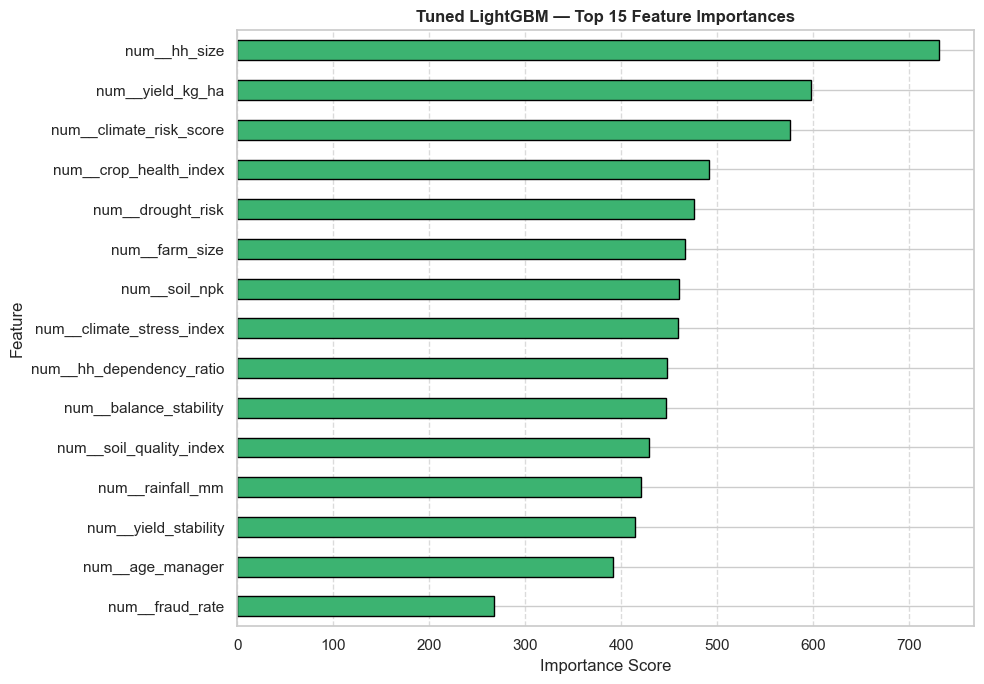

In [ ]:

fig = plt.figure(figsize=(10, 7))

# Use the EXACT training data used in model fitting
feature_names = X_train_resampled.columns

# Get feature importances
importances_tuned_lgb = pd.Series(
    lgb_search.best_estimator_.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

# Plot feature importance
importances_tuned_lgb.sort_values().plot(
    kind='barh',
    color='mediumseagreen',
    edgecolor='k'
)

plt.title('Tuned LightGBM — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Insights
- num__hh_size (Household Size) is by far the most influential feature, indicating it plays a dominant role in the model's predictions.

- num__yield_kg_ha (Crop Yield in kg per hectare) ranks as the second most important feature, showing strong predictive power.

- num__climate_risk_score and num__crop_health_index are also among the top contributors, highlighting the significance of climate threats and crop vitality.

- The model heavily relies on a mix of socioeconomic factors and agricultural/environmental features, which aligns well with the domain.

### Interpretation
This feature importance plot confirms that the model has learned meaningful patterns from the data. Household demographics, historical crop productivity, and environmental stress factors (especially climate risk) appear to be the strongest predictors. This gives high confidence in the model's decisions and provides valuable insights for domain experts.

## MODEL Evaluation- Tuned Models

In [ ]:
best_rf = rf_search.best_estimator_
best_lgbm = lgb_search.best_estimator_

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Tuned Random Forest": best_rf,
    "Tuned LightGBM": best_lgbm
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

df_results = pd.DataFrame(results).set_index("Model")
print("\n========== TUNED MODEL COMPARISON ==========\n")
print(df_results.round(4))


========== TUNED MODEL COMPARISON ==========

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Tuned Random Forest    0.8479     0.5987  0.6355    0.6166   0.9071
Tuned LightGBM         0.8541     0.6039  0.7016    0.6491   0.9104


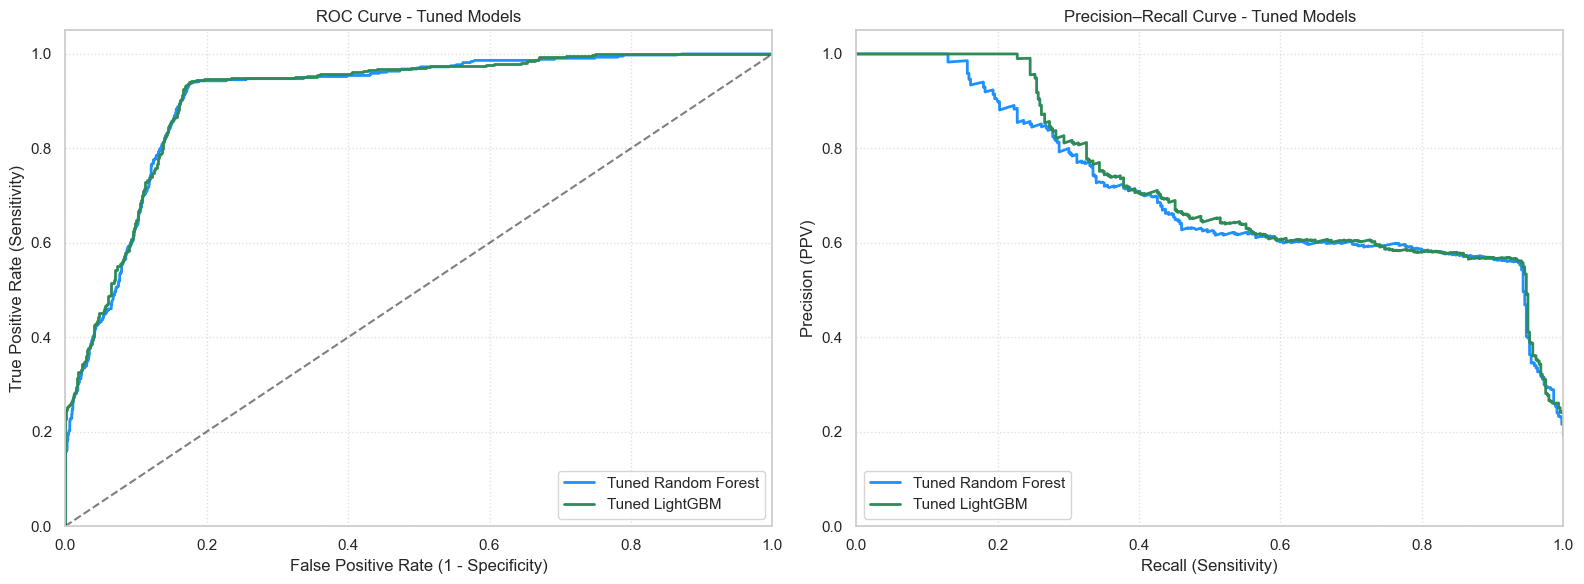

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MODELS (ONLY TUNED ONES)
models = {
    "Tuned Random Forest": best_rf,
    "Tuned LightGBM": best_lgbm
}

# COLORS
colors = {
    "Tuned Random Forest": "dodgerblue",
    "Tuned LightGBM": "seagreen"
}

# LOOP THROUGH MODELS
for name, model_obj in models.items():

    X_test_compatible = X_test_processed.copy()
    # PROBABILITIES
    y_prob = model_obj.predict_proba(X_test_compatible)[:, 1]
    # ROC CURVE

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    axes[0].plot(
        fpr, tpr,
        label=f"{name}",
        color=colors.get(name, "gray"),
        lw=2
    )


    # PRECISION-RECALL CURVE
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    axes[1].plot(
        recall, precision,
        label=f"{name}",
        color=colors.get(name, "gray"),
        lw=2
    )

# ROC FORMATTING
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve - Tuned Models')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=':', alpha=0.6)

# PR FORMATTING
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision–Recall Curve - Tuned Models')
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
df_results.style.background_gradient(cmap="Blues")

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Tuned Random Forest,0.847940,0.598712,0.635535,0.616575,0.907074
Tuned LightGBM,0.854075,0.603922,0.701595,0.649104,0.910408


## Model Performance Comparison (Tuned Random Forest vs Tuned LightGBM)


### Interpretation of Results

#### Accuracy
The Tuned LightGBM model achieves a slightly higher accuracy (0.8541) compared to the Tuned Random Forest (0.8479), indicating it correctly classifies more overall observations.

#### Precision
Both models show similar precision, with LightGBM (0.6039) slightly outperforming Random Forest (0.5987). This suggests LightGBM produces fewer false positives.

#### Recall
Recall shows a more noticeable difference, where LightGBM (0.7016) significantly outperforms Random Forest (0.6355). This indicates that LightGBM is better at identifying actual positive cases and misses fewer true positives.

#### F1-Score
The Tuned LightGBM model achieves a higher F1-score (0.6491) compared to Random Forest (0.6166), showing a better balance between precision and recall.

#### AUC-ROC
Both models perform strongly in distinguishing between classes, but LightGBM (0.9104) slightly exceeds Random Forest (0.9071), indicating better overall classification capability.



###  Final Conclusion

Both tuned models demonstrate strong predictive performance with AUC-ROC values above 0.90, indicating excellent classification ability.

However, the **Tuned LightGBM model consistently outperforms the Tuned Random Forest model across all key evaluation metrics**, particularly in recall and F1-score. This indicates that LightGBM is more effective at correctly identifying positive cases while maintaining a balanced trade-off between precision and recall.


# SHAP Analysis

SHAP values were used to understand how the model makes decisions at both **global** and **local** levels.

In [ ]:
# Create SHAP Explainer for LightGBM
explainer = shap.TreeExplainer(lgb_search.best_estimator_)

# Calculate SHAP values (use a sample if dataset is very large)
shap_values = explainer.shap_values(X_test_processed)

# For binary classification, SHAP returns values for both classes
# We usually use the positive class (index 1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print(isinstance(shap_values, list))

False


## false-shap_values is now likely a NumPy array or matrix after

## Global interpretability & Beewarm plot
**Key Observations**:
Key Insights from This Plot

**yield_kg_ha** is the most important feature overall.
   - High yield (red) tends to push predictions to the **left** (negative SHAP).
   - Low yield (blue) pushes predictions to the **right**.

**drought_risk** is the second most influential feature.
   - High drought risk (red) strongly pushes predictions toward the **positive class** (right side).
   - This confirms `drought_risk` has a high negative impact when elevated.

** tx_frequency** (Transaction Frequency) shows moderate importance.
   - High frequency (red) appears to have mixed but notable effect

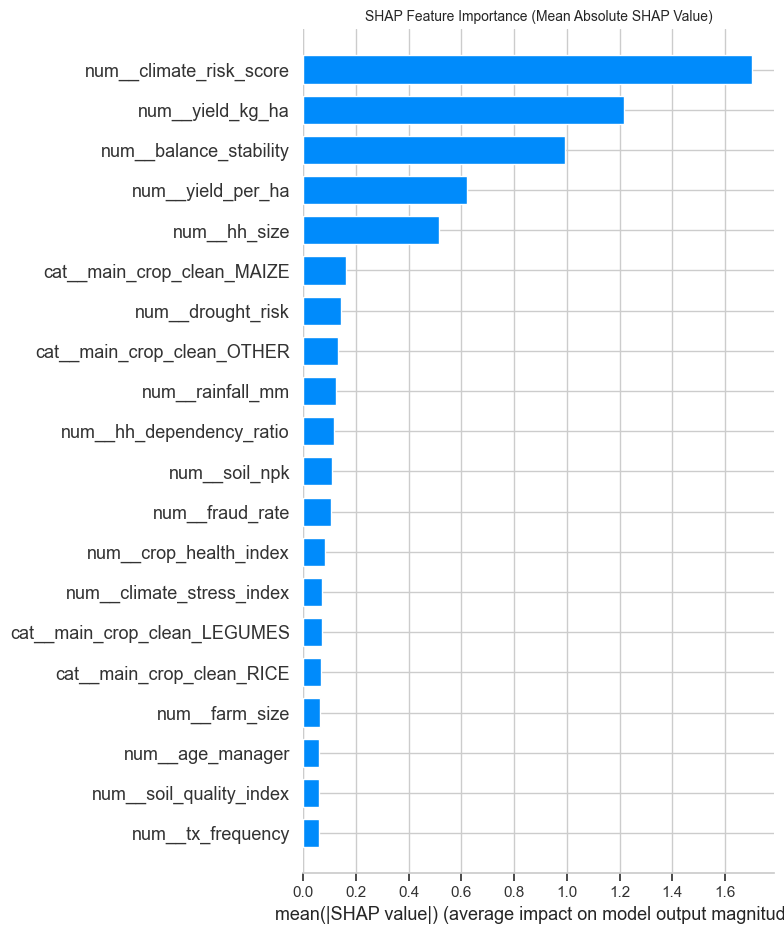

In [ ]:
#Summary Plot (Global Interpretability)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean Absolute SHAP Value)", fontsize=10)
plt.tight_layout()
plt.show()


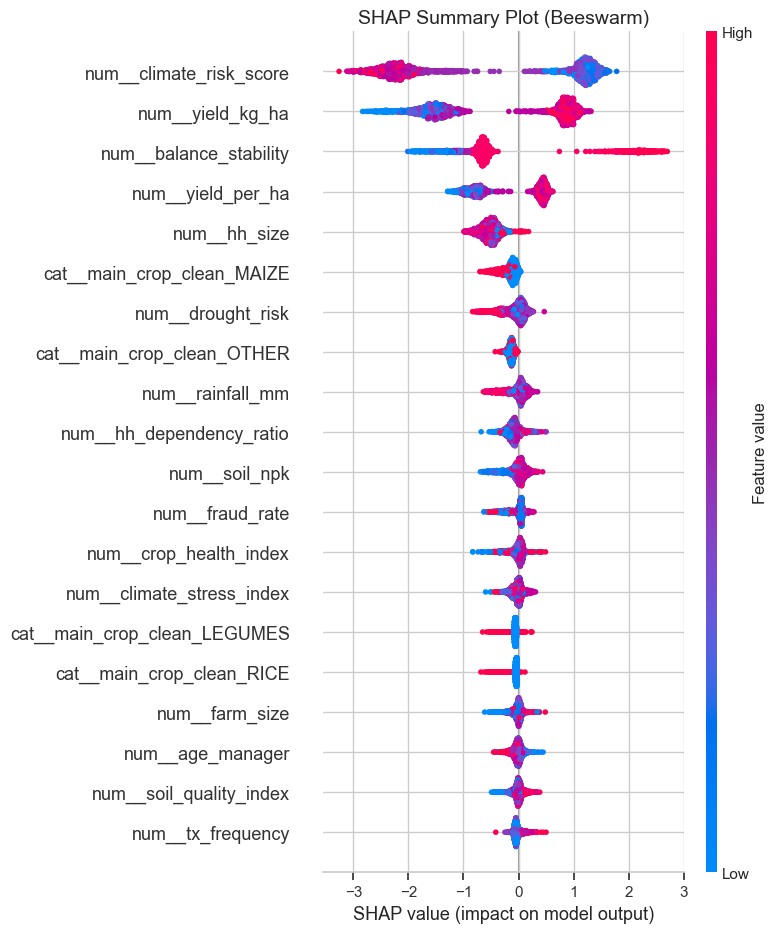

In [ ]:
# Beeswarm Plot (Most Informative)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_processed, show=False)
plt.title("SHAP Summary Plot (Beeswarm)", fontsize=14)
plt.tight_layout()
plt.show()

### Business Insights from SHAP:
- The model is **highly interpretable** and aligns well with agronomic and financial domain knowledge.  
  This alignment increases confidence that the model is learning genuine and useful patterns rather than noise.

- Stakeholders can **trust and understand** the model’s decisions, making it suitable for real-world applications such as loan approvals, insurance risk assessment, government support programs, and early warning systems.

### Strategic Takeaway:
Success in reducing risk and improving outcomes depends more on **productivity (yield)** and **climate resilience (drought management)** than on farm size or other structural factors. Organizations should prioritize programs that directly enhance yield and protect against drought.

# Conclusion
The tuned LightGBM model demonstrates strong predictive performance in classifying [target variable — e.g., crop failure risk / high yield potential].

- The model effectively captures important patterns in the agricultural dataset, particularly environmental stress factors.
- The combination of hyperparameter tuning and robust cross-validation gives us high confidence in the model's generalization ability. The strong emphasis on drought_risk and yield_kg_ha aligns well with domain knowledge in agronomy.

## Practical Recommendations
- Use the model to automatically assess risk and **determine the appropriate loan amount** a farmer should receive.
- Prioritize **drought risk monitoring** as a key criterion when approving agricultural loans.
- Build an **early warning system** to identify high-risk farmers and offer them smaller loans or risk-mitigation support (e.g., crop insurance).
- Integrate real-time data on **soil moisture and weather** to improve loan risk scoring accuracy.
- Deploy the model in a **loan application system** (mobile or web) to enable faster and more objective loan processing for smallholder farmers.

---

##  Future Work

- Incorporate **time-series features** (historical yield, rainfall, etc.) for better repayment prediction.
- Explore advanced models such as **TabNet** or **Transformer-based** architectures.
- Conduct a **cost-benefit analysis** of model deployment, including default rate reduction and increased loan portfolio profitability.

# Saving model for deployment

In [ ]:
import joblib

## Save the Model

In [ ]:
joblib.dump(lgb_search , os.path.join(model_path, 'lightgbm_model.pkl'))

['c:\\Users\\hp\\Desktop\\DS_FT15\\PHASE_5_PROJECT\\AGRISCORE-\\Models\\lightgbm_model.pkl']

## Load the Saved Model

In [ ]:
loaded_model = joblib.load(os.path.join(model_path , 'lightgbm_model.pkl'))

# Make Predictions

In [ ]:
predictions = loaded_model.predict(X_test_processed)
predictions.tolist()

[0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,


# Saving SHAP explainer for deployment

In [ ]:
# Create explainer

joblib.dump(explainer ,  os.path.join(model_path , "agriscore_SHAP_explainer.pkl"))

['c:\\Users\\hp\\Desktop\\DS_FT15\\PHASE_5_PROJECT\\AGRISCORE-\\Models\\agriscore_SHAP_explainer.pkl']

In [ ]:
explainer = joblib.load(os.path.join(model_path , "agriscore_SHAP_explainer.pkl"))

In [ ]:
print(explainer.shap_values(X_test_processed))

[[-0.29973677 -0.19094645 -0.02924088 ... -0.00941475 -0.03887679
   0.        ]
 [-0.4762248  -0.07570746 -0.07677173 ... -0.01071198 -0.01756662
   0.        ]
 [-0.72384054  0.0151749  -0.13821163 ... -0.00454323 -0.0311551
   0.        ]
 ...
 [-0.57953568 -0.11129434 -0.01205156 ... -0.01505797 -0.04958288
   0.        ]
 [-0.57893469 -0.15131533 -0.053533   ... -0.00523297 -0.03383352
   0.        ]
 [-0.45740957 -0.28266546  0.12976897 ... -0.00381685 -0.04386008
   0.        ]]
